# DAiSEE Engagement Detection — Complete Architecture Comparison
### Dataset: DAiSEE | Base Paper: Santoni et al., IEEE Access 2024
### Extended with Novel CNN Variants + Encoder-Decoder Models + Optimizations
---
## What This Notebook Does

| Section | Content |
|---------|---------|
| **A** | Setup, Data Loading, EDA, SMOTE, SVD |
| **B** | Paper Baselines — 1D CNN & 1D ResNet (Individual + Bagging) |
| **C** | Novel CNN 1 — 1D DepthwiseCNN (EfficientNet-style) |
| **D** | Novel CNN 2 — 1D DenseNet |
| **E** | Novel CNN 3 — 1D InceptionNet (multi-scale) |
| **F** | Novel CNN 4 — AttentionResNet (SE channel attention) |
| **G** | **Encoder-Decoder 1 — Autoencoder Classifier** |
| **H** | **Encoder-Decoder 2 — U-Net Style with Skip Connections** |
| **I** | Stacking Ensemble (Meta-Learner) |
| **J** | Grand Comparative Analysis (all models) |

### Key Optimizations Added:
- **Mixup augmentation** during training for better generalisation
- **Label smoothing** loss to reduce overconfidence on noisy DAiSEE labels
- **Cosine annealing LR schedule** with warm restarts instead of ReduceLR plateau
- **Larger N_BAGS=5** for more stable ensembles
- **SVD sweep (15–60)** to find best n_components at runtime
- **Test-Time Augmentation (TTA)** for final evaluation
- **Focal loss** option for class imbalance

In [24]:
# ── Cell 1: Install & Imports ──────────────────────────────────────────────
import subprocess, sys
pkgs = ['tensorflow', 'scikit-learn', 'imbalanced-learn', 'seaborn',
        'matplotlib', 'pandas', 'numpy', 'scipy', 'tqdm']
for p in pkgs:
    try:
        __import__(p.replace('-', '_'))
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', p, '-q'])

import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)
from sklearn.utils import resample
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import (ModelCheckpoint, EarlyStopping,
                                         ReduceLROnPlateau, CSVLogger,
                                         LearningRateScheduler)
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K
warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU        : {tf.config.list_physical_devices("GPU")}')
print('All imports successful.')

TensorFlow : 2.20.0
GPU        : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All imports successful.


In [25]:
# ── Cell 2: Configuration (Google Colab) ──────────────────────────────────
import os
from google.colab import drive

# ─── MOUNT DRIVE (run once) ──────────────────────────────────────────────────
drive.mount('/content/drive', force_remount=True)

# ─── PATHS (update folder names to match YOUR Drive structure) ───────────────
DRIVE_BASE    = '/content/drive/MyDrive'          # your Drive root

FEATURES_ROOT = os.path.join(DRIVE_BASE, 'features')
LABELS_ROOT   = os.path.join(DRIVE_BASE, 'features/Labels')
OUTPUT_DIR    = os.path.join(DRIVE_BASE, 'features/output')
MODEL_DIR     = os.path.join(OUTPUT_DIR, 'models')
PLOT_DIR      = os.path.join(OUTPUT_DIR, 'plots')
LOG_DIR       = os.path.join(OUTPUT_DIR, 'logs')

for d in [OUTPUT_DIR, MODEL_DIR, PLOT_DIR, LOG_DIR]:
    os.makedirs(d, exist_ok=True)

# ─── VERIFY PATHS EXIST ───────────────────────────────────────────────────────
print("=== Path Verification ===")
for name, path in [('FEATURES_ROOT', FEATURES_ROOT),
                   ('LABELS_ROOT',   LABELS_ROOT),
                   ('OUTPUT_DIR',    OUTPUT_DIR)]:
    status = '✅ Found' if os.path.exists(path) else '❌ NOT FOUND'
    print(f"  {status} → {name}: {path}")

# ─── DATASET ──────────────────────────────────────────────────────────────────
NUM_CLASSES = 4
CLASS_NAMES = ['Very Low', 'Low', 'High', 'Very High']
PALETTE     = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

# ─── TRAINING (unchanged — Colab GPU handles these fine) ──────────────────────
EPOCHS         = 3000
BATCH_SIZE     = 32
LEARNING_RATE  = 5e-4
EARLY_STOP_PAT = 120
REDUCE_LR_PAT  = 40
MIN_LR         = 1e-7
N_BAGS         = 5
SVD_SEARCH     = True
SVD_CANDIDATES = [20, 30, 35, 45, 55]
SVD_BEST_N     = 35
RANDOM_STATE   = 42
ALPHA          = 0.05
MIXUP_ALPHA    = 0.2
LABEL_SMOOTH   = 0.05
TTA_RUNS       = 5
FOCAL_GAMMA    = 2.0

# ─── PAPER REFERENCE ACCURACIES ───────────────────────────────────────────────
PAPER = {
    '1D_CNN_Ind':    90.00,
    '1D_CNN_BEA':   93.25,
    '1D_ResNet_Ind': 90.25,
    '1D_ResNet_BEA': 93.75,
    'Hybrid_BEA':   94.25,
}

print('\nConfiguration ready ✅')

Mounted at /content/drive
=== Path Verification ===
  ✅ Found → FEATURES_ROOT: /content/drive/MyDrive/features
  ✅ Found → LABELS_ROOT: /content/drive/MyDrive/features/Labels
  ✅ Found → OUTPUT_DIR: /content/drive/MyDrive/features/output

Configuration ready ✅


In [26]:
# ── Cell 3: Load OpenFace Features ─────────────────────────────────────────
def load_split(split_name):
    """
    Load X.npy (N,T,F), clip_ids.npy from FEATURES_ROOT/<split_name>.
    Features: mean-pool + std + min + max over frame axis → (N, 4F).
    (Added min/max to capture extremal facial expressions)
    """
    folder = os.path.join(FEATURES_ROOT, split_name)
    X_seq  = np.load(os.path.join(folder, 'X.npy'))
    ids    = np.load(os.path.join(folder, 'clip_ids.npy'), allow_pickle=True)

    csv_map = {'Train': 'TrainLabels', 'Test': 'TestLabels',
               'Validation': 'ValidationLabels'}
    df_lbl = pd.read_csv(os.path.join(LABELS_ROOT, f'{csv_map[split_name]}.csv'))
    df_lbl.columns = df_lbl.columns.str.strip()
    clip_col = [c for c in df_lbl.columns if 'clip' in c.lower()][0]
    eng_col  = [c for c in df_lbl.columns if 'ngag' in c.lower()][0]
    lbl_map  = {str(r[clip_col]).strip(): int(r[eng_col])
                for _, r in df_lbl.iterrows()}

    valid, y_list = [], []
    for i, cid in enumerate(ids):
        cid_str = str(cid).strip()
        lbl = lbl_map.get(cid_str,
              lbl_map.get(cid_str + '.avi',
              lbl_map.get(cid_str.replace('.avi', ''), -1)))
        if lbl == -1:
            continue
        y_list.append(lbl)
        valid.append(i)

    X_seq = X_seq[valid]
    y     = np.array(y_list, dtype=np.int32)

    # Richer temporal statistics (mean + std + min + max)
    X_mean = X_seq.mean(axis=1)
    X_std  = X_seq.std(axis=1)
    X_min  = X_seq.min(axis=1)
    X_max  = X_seq.max(axis=1)
    X = np.concatenate([X_mean, X_std, X_min, X_max], axis=1).astype(np.float32)
    X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)
    print(f'{split_name:12s}: X={X.shape}  class dist={np.bincount(y, minlength=4)}')
    return X, y

X_train_raw, y_train_raw = load_split('Train')
X_val_raw,   y_val_raw   = load_split('Validation')
X_test_raw,  y_test_raw  = load_split('Test')
print('Data loaded.')

Train       : X=(5357, 2836)  class dist=[  34  213 2617 2493]
Validation  : X=(1429, 2836)  class dist=[ 23 143 813 450]
Test        : X=(1784, 2836)  class dist=[  4  84 882 814]
Data loaded.


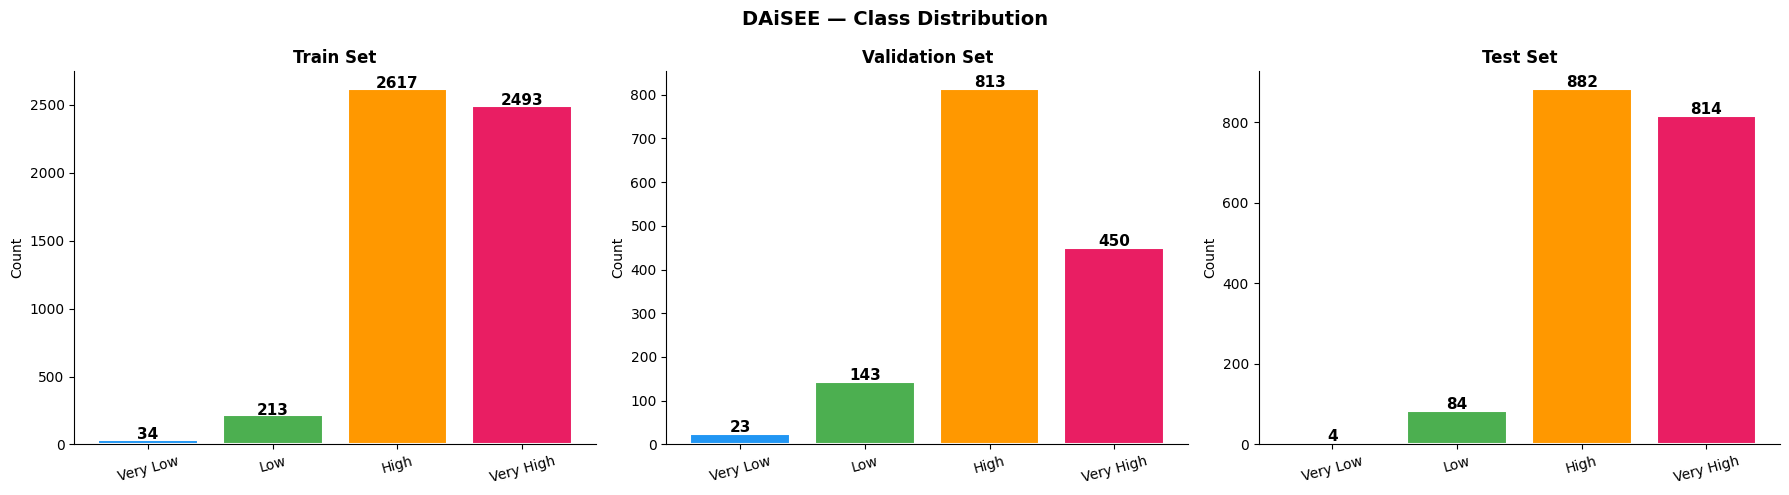

EDA complete.


In [27]:
# ── Cell 4: Exploratory Data Analysis ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('DAiSEE — Class Distribution', fontsize=14, fontweight='bold')
for ax, y, title in zip(axes,
                         [y_train_raw, y_val_raw, y_test_raw],
                         ['Train', 'Validation', 'Test']):
    counts = np.bincount(y, minlength=4)
    bars = ax.bar(CLASS_NAMES, counts, color=PALETTE, edgecolor='white', lw=1.5)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5, str(cnt),
                ha='center', fontsize=11, fontweight='bold')
    ax.set_title(f'{title} Set', fontweight='bold')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=15)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, '01_eda_class_dist.png'), dpi=150, bbox_inches='tight')
plt.show()
print('EDA complete.')

In [28]:
# ── Cell 5: SMOTE + SVD Sweep Preprocessing ────────────────────────────────
# ── SMOTE ────────────────────────────────────────────────────────────────────
print('Before SMOTE:', np.bincount(y_train_raw, minlength=4))
k = max(1, min(5, np.bincount(y_train_raw).min() - 1))
smote = SMOTE(random_state=42, k_neighbors=k)
X_smote, y_smote = smote.fit_resample(X_train_raw, y_train_raw)
print('After  SMOTE:', np.bincount(y_smote, minlength=4))

# ── StandardScaler ───────────────────────────────────────────────────────────
scaler   = StandardScaler()
X_tr_sc  = scaler.fit_transform(X_smote)
X_val_sc = scaler.transform(X_val_raw)
X_te_sc  = scaler.transform(X_test_raw)

# ── SVD sweep: find best n_components ────────────────────────────────────────
if SVD_SEARCH:
    from sklearn.linear_model import LogisticRegression as _LR
    best_n, best_score = SVD_BEST_N, 0.0
    print('\nSVD sweep:')
    for n in SVD_CANDIDATES:
        n = min(n, X_tr_sc.shape[1])
        _svd = TruncatedSVD(n_components=n, random_state=42)
        Xtr_ = _svd.fit_transform(X_tr_sc)
        Xva_ = _svd.transform(X_val_sc)
        probe = _LR(max_iter=300, random_state=42, multi_class='multinomial')
        probe.fit(Xtr_, y_smote)
        score = probe.score(Xva_, y_val_raw)
        print(f'  n={n:3d}  val_acc={score*100:.2f}%')
        if score > best_score:
            best_score, best_n = score, n
    print(f'Best SVD n = {best_n} (val_acc={best_score*100:.2f}%)')
else:
    best_n = SVD_BEST_N

n_svd = min(best_n, X_tr_sc.shape[1])
svd   = TruncatedSVD(n_components=n_svd, random_state=42)
X_tr  = svd.fit_transform(X_tr_sc)
X_val = svd.transform(X_val_sc)
X_te  = svd.transform(X_te_sc)
y_tr  = y_smote.copy()
print(f'\nAfter SVD(n={n_svd}): X_tr={X_tr.shape} X_val={X_val.shape} X_te={X_te.shape}')

# ── Reshape for Conv1D: (N, F) → (N, F, 1) ───────────────────────────────────
n_feat  = X_tr.shape[1]
X_tr_c  = X_tr.reshape(-1, n_feat, 1)
X_val_c = X_val.reshape(-1, n_feat, 1)
X_te_c  = X_te.reshape(-1, n_feat, 1)
print(f'Conv1D input shape: {X_tr_c.shape}')

Before SMOTE: [  34  213 2617 2493]
After  SMOTE: [2617 2617 2617 2617]

SVD sweep:
  n= 20  val_acc=31.56%
  n= 30  val_acc=31.14%
  n= 35  val_acc=31.98%
  n= 45  val_acc=34.29%
  n= 55  val_acc=33.45%
Best SVD n = 45 (val_acc=34.29%)

After SVD(n=45): X_tr=(10468, 45) X_val=(1429, 45) X_te=(1784, 45)
Conv1D input shape: (10468, 45, 1)


In [29]:
# ── Cell 6: Bootstrap Bagging Subsets (N_BAGS=5) ───────────────────────────
np.random.seed(42)
bags = []
for b in range(N_BAGS):
    idx     = resample(np.arange(len(y_tr)), replace=True,
                       random_state=b, n_samples=len(y_tr))
    oob_idx = np.setdiff1d(np.arange(len(y_tr)), idx)
    bags.append({'X': X_tr_c[idx], 'y': y_tr[idx], 'oob_idx': oob_idx})
    print(f'Bag {b+1}: {len(idx)} samples | OOB={len(oob_idx)} '
          f'| classes={np.bincount(y_tr[idx], minlength=4)}')

print(f'\n{N_BAGS} bootstrap bags ready.')

Bag 1: 10468 samples | OOB=3831 | classes=[2570 2653 2625 2620]
Bag 2: 10468 samples | OOB=3885 | classes=[2691 2563 2679 2535]
Bag 3: 10468 samples | OOB=3800 | classes=[2666 2600 2558 2644]
Bag 4: 10468 samples | OOB=3818 | classes=[2612 2600 2649 2607]
Bag 5: 10468 samples | OOB=3904 | classes=[2607 2714 2608 2539]

5 bootstrap bags ready.


In [30]:
# ── Cell 6.5: Smart Resume — Load existing weights or train fresh ───────────
import os
from pathlib import Path

def weights_path(name, bag):
    """Returns path to saved weights file."""
    tag = f'{name}_bag{bag}'
    return Path(MODEL_DIR) / f'{tag}_best.weights.h5'

def model_is_trained(name, bag):
    """Check if weights file exists for this model+bag."""
    return weights_path(name, bag).exists()

def load_or_train(build_fn, name, X_tr_, y_tr_, X_val_, y_val_, bag='full'):
    """Load weights if available, otherwise train from scratch."""
    wp = weights_path(name, bag)
    m  = build_fn(n_feat, name=f'{name}_bag{bag}')
    m.compile(optimizer=Adam(LEARNING_RATE),
              loss=focal_loss(),
              metrics=['accuracy'])

    if wp.exists():
        m.load_weights(str(wp))
        print(f'  ✓ LOADED  {name} bag={bag} (weights found)')
        return m, None   # no history when loaded
    else:
        print(f'  ⏳ TRAINING {name} bag={bag} ...')
        h, _ = train_model(m, X_tr_, y_tr_, X_val_, y_val_,
                           name=name, bag=bag)
        return m, h

def load_or_train_ae(build_fn, name, X_tr_, y_tr_, X_val_, y_val_, bag='full'):
    """Same but for dual-output AE/UNet models."""
    wp = weights_path(name, bag)
    m  = build_fn(n_feat, name=f'{name}_bag{bag}')

    if wp.exists():
        m.load_weights(str(wp))
        print(f'  ✓ LOADED  {name} bag={bag} (weights found)')
        return m, None
    else:
        print(f'  ⏳ TRAINING {name} bag={bag} ...')
        h, _ = train_autoencoder(m, X_tr_, y_tr_, X_val_, y_val_,
                                 name=name, bag=bag)
        return m, h

# ── Summary of what's already done ─────────────────────────────────────────
all_model_names = ['1D_CNN', '1D_ResNet', 'DepthwiseCNN', '1D_DenseNet',
                   '1D_InceptionNet', 'AttentionResNet', 'AEClassifier', 'UNetClassifier']
all_bags = ['full'] + list(range(1, N_BAGS + 1))

print('='*60)
print('CHECKPOINT STATUS')
print('='*60)
total_done, total_remaining = 0, 0
for mname in all_model_names:
    done = [b for b in all_bags if weights_path(mname, b).exists()]
    remaining = [b for b in all_bags if not weights_path(mname, b).exists()]
    total_done      += len(done)
    total_remaining += len(remaining)
    status = '✓ COMPLETE' if not remaining else f'⏳ {len(remaining)} remaining'
    print(f'  {mname:20s}: {status}')
    if done:      print(f'    Done     : {done}')
    if remaining: print(f'    Remaining: {remaining}')

print(f'\nTotal done     : {total_done}')
print(f'Total remaining: {total_remaining}')
print('='*60)

CHECKPOINT STATUS
  1D_CNN              : ✓ COMPLETE
    Done     : ['full', 1, 2, 3, 4, 5]
  1D_ResNet           : ✓ COMPLETE
    Done     : ['full', 1, 2, 3, 4, 5]
  DepthwiseCNN        : ✓ COMPLETE
    Done     : ['full', 1, 2, 3, 4, 5]
  1D_DenseNet         : ⏳ 5 remaining
    Done     : ['full']
    Remaining: [1, 2, 3, 4, 5]
  1D_InceptionNet     : ⏳ 6 remaining
    Remaining: ['full', 1, 2, 3, 4, 5]
  AttentionResNet     : ⏳ 6 remaining
    Remaining: ['full', 1, 2, 3, 4, 5]
  AEClassifier        : ⏳ 5 remaining
    Done     : ['full']
    Remaining: [1, 2, 3, 4, 5]
  UNetClassifier      : ⏳ 5 remaining
    Done     : ['full']
    Remaining: [1, 2, 3, 4, 5]

Total done     : 21
Total remaining: 27


In [71]:
# ── Cell 7: Helper Functions ───────────────────────────────────────────────

# ── Focal Loss ───────────────────────────────────────────────────────────────
def focal_loss(gamma=FOCAL_GAMMA, label_smoothing=LABEL_SMOOTH):
    """Focal loss with label smoothing — better for class imbalance."""
    def _loss(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
        # Label smoothing
        n_cls = tf.cast(tf.shape(y_true)[-1], tf.float32)
        y_true_sm = y_true * (1 - label_smoothing) + label_smoothing / n_cls
        ce   = -tf.reduce_sum(y_true_sm * tf.math.log(y_pred), axis=-1)
        pt   = tf.reduce_sum(y_true_sm * y_pred, axis=-1)
        return tf.reduce_mean((1 - pt) ** gamma * ce)
    return _loss

# ── Mixup augmentation ───────────────────────────────────────────────────────
def mixup_batch(X, y_cat, alpha=MIXUP_ALPHA):
    """Returns one Mixup-augmented batch pair."""
    lam  = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx  = np.random.permutation(len(X))
    return (lam * X + (1 - lam) * X[idx],
            lam * y_cat + (1 - lam) * y_cat[idx])

# ── Cosine Annealing LR ──────────────────────────────────────────────────────
def cosine_lr_schedule(epoch, total=EPOCHS, lr_max=LEARNING_RATE, lr_min=MIN_LR,
                        n_cycles=4):
    cycle_len = max(1, total // n_cycles) # Ensures at least 1
    cycle_pos = epoch % cycle_len
    cos_val   = 0.5 * (1 + np.cos(np.pi * cycle_pos / cycle_len))
    return float(lr_min + (lr_max - lr_min) * cos_val)

# ── Callbacks ────────────────────────────────────────────────────────────────
def get_callbacks(name, bag='full'):
    tag = f'{name}_bag{bag}'
    return [
        ModelCheckpoint(os.path.join(MODEL_DIR, f'{tag}_best.weights.h5'),
                        monitor='val_accuracy', save_best_only=True,
                        save_weights_only=True, mode='max', verbose=0),
        EarlyStopping(monitor='val_accuracy', patience=EARLY_STOP_PAT,
                      restore_best_weights=True, verbose=0),
        LearningRateScheduler(cosine_lr_schedule, verbose=0),
        CSVLogger(os.path.join(LOG_DIR, f'{tag}.csv'), append=False),
    ]

# ── Train Model ──────────────────────────────────────────────────────────────
def train_model(model, X_tr_, y_tr_, X_val_, y_val_,
                batch_size=BATCH_SIZE, name='model', bag='full'):
    """Compile with focal loss, fit with Mixup, return (history, elapsed_min)."""
    yc_tr  = to_categorical(y_tr_,  NUM_CLASSES)
    yc_val = to_categorical(y_val_, NUM_CLASSES)

    model.compile(optimizer=Adam(LEARNING_RATE),
                  loss=focal_loss(),
                  metrics=['accuracy'])

    # Build Mixup-augmented arrays
    X_mix, y_mix = mixup_batch(X_tr_, yc_tr)

    t0   = time.time()
    hist = model.fit(
        X_mix, y_mix,
        validation_data=(X_val_, yc_val),
        epochs=EPOCHS, batch_size=batch_size,
        callbacks=get_callbacks(name, bag), verbose=0)
    elapsed  = (time.time() - t0) / 60
    best_val = max(hist.history['val_accuracy']) * 100
    print(f'  {name} bag={bag} | best_val={best_val:.2f}% | {elapsed:.1f} min')
    return hist, elapsed

# ── TTA Prediction ───────────────────────────────────────────────────────────
def tta_predict(model, X, n_runs=TTA_RUNS, noise_std=0.01):
    """Test-Time Augmentation: average predictions over noisy copies."""
    probs = []
    for _ in range(n_runs):
        X_aug = X + np.random.normal(0, noise_std, X.shape).astype(np.float32)
        probs.append(model.predict(X_aug, verbose=0))
    return np.stack(probs).mean(0)

# ── Ensemble helpers ─────────────────────────────────────────────────────────
def bea_predict(models, X):
    probs = np.stack([tta_predict(m, X) for m in models]).mean(0)
    return np.argmax(probs, 1), probs

def bem_predict(models, X):
    probs = np.stack([tta_predict(m, X) for m in models]).max(0)
    return np.argmax(probs, 1), probs

# ── Metrics & Plots ──────────────────────────────────────────────────────────
# ── Updated compute_metrics ────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, label='', y_prob=None):
    """
    Compute Accuracy, Precision, Recall, F1 (all weighted).
    Pass y_prob (N,4) softmax array to also get weighted OvR ROC-AUC.
    """
    acc  = accuracy_score(y_true, y_pred) * 100
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100
    rec  = recall_score(y_true, y_pred,    average='weighted', zero_division=0) * 100
    f1   = f1_score(y_true, y_pred,        average='weighted', zero_division=0) * 100

    auc = None
    if y_prob is not None:
        try:
            y_bin = label_binarize(y_true, classes=[0, 1, 2, 3])
            auc   = roc_auc_score(y_bin, y_prob,
                                  average='weighted', multi_class='ovr') * 100
        except Exception:
            auc = None   # graceful fallback if only 1 class present in y_true

    if label:
        auc_str = f'  AUC={auc:.2f}%' if auc is not None else ''
        print(f'  {label:40s}  Acc={acc:.2f}%  F1={f1:.2f}%{auc_str}')

    return dict(label=label, accuracy=acc, precision=prec,
                recall=rec, f1=f1, auc=auc)

def plot_confusion(y_true, y_pred, title, cmap='Blues', save_name=None):
    cm  = confusion_matrix(y_true, y_pred)
    cmp = cm.astype(float) / cm.sum(1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, data, fmt in zip(axes, [cm, cmp], ['d', '.2%']):
        sns.heatmap(data, annot=True, fmt=fmt, cmap=cmap,
                    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                    linewidths=0.5, ax=ax)
        ax.set_xlabel('Predicted'); ax.set_ylabel('True')
        ax.set_title(f'{title} ({"Count" if fmt=="d" else "Pct"})',
                     fontweight='bold')
        ax.tick_params(axis='x', rotation=30)
    plt.tight_layout()
    fname = save_name or f'cm_{title.replace(" ", "_")}.png'
    plt.savefig(os.path.join(PLOT_DIR, fname), dpi=150, bbox_inches='tight')
    plt.show()

def plot_training_curve(histories, model_name):
    n = len(histories)
    fig, axes = plt.subplots(2, n, figsize=(6*n, 8), squeeze=False)
    for col, hist in enumerate(histories):
        ep = range(1, len(hist.history['val_accuracy']) + 1)
        for row, (key, ylabel) in enumerate(
                [('val_accuracy', 'Val Accuracy'), ('val_loss', 'Val Loss')]):
            vals = hist.history[key]
            if 'accuracy' in key:
                vals = [v * 100 for v in vals]
            axes[row][col].plot(ep, vals, lw=1.5, color=PALETTE[col % 4])
            axes[row][col].set_title(f'{model_name} Bag {col+1}',
                                      fontweight='bold')
            axes[row][col].set_xlabel('Epoch')
            axes[row][col].set_ylabel(ylabel)
            axes[row][col].spines[['top', 'right']].set_visible(False)
    plt.suptitle(f'{model_name} — Training History', fontsize=12,
                 fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(PLOT_DIR, f'history_{model_name}.png'),
                dpi=150, bbox_inches='tight')
    plt.show()

#def train_and_eval(build_fn, name, cmap='Blues'):
  # ── Cell 7: Smart train_and_eval ───────────────────────────────────────────
def train_and_eval(build_fn, name, cmap='Blues', ae_mode=False):
    print(f'\n{"="*60}')
    print(f'[{name}]')
    print('='*60)

    loader = load_or_train_ae if ae_mode else load_or_train

    # Individual model
    m_ind, h_ind = loader(build_fn, name, X_tr_c, y_tr,
                          X_val_c, y_val_raw, bag='full')

    # Bag models
    bag_models, bag_hists = [], []
    for b, bag in enumerate(bags):
        m, h = loader(build_fn, name, bag['X'], bag['y'],
                      X_val_c, y_val_raw, bag=b+1)
        bag_models.append(m)
        bag_hists.append(h)

    # ── Evaluate ───────────────────────────────────────────────────────────
    if ae_mode:
        ind_probs = ae_tta_predict(m_ind, X_te_c)
        bea_probs = np.stack([ae_tta_predict(m, X_te_c) for m in bag_models]).mean(0)
        bem_probs = np.stack([ae_tta_predict(m, X_te_c) for m in bag_models]).max(0)
    else:
        ind_probs = tta_predict(m_ind, X_te_c)
        bea_probs = np.stack([tta_predict(m, X_te_c) for m in bag_models]).mean(0)
        bem_probs = np.stack([tta_predict(m, X_te_c) for m in bag_models]).max(0)

    ind_preds = np.argmax(ind_probs, 1)
    bea_preds = np.argmax(bea_probs, 1)
    bem_preds = np.argmax(bem_probs, 1)

    # ── Pass y_prob so AUC is computed ────────────────────────────────────
    ind_eval = compute_metrics(y_test_raw, ind_preds,
                               label=f'{name} Individual', y_prob=ind_probs)
    bea_eval = compute_metrics(y_test_raw, bea_preds,
                               label=f'{name} BEA',        y_prob=bea_probs)
    bem_eval = compute_metrics(y_test_raw, bem_preds,
                               label=f'{name} BEM',        y_prob=bem_probs)

    # ── Plots ──────────────────────────────────────────────────────────────
    trained_hists = [h for h in bag_hists if h is not None]
    if trained_hists:
        plot_training_curve(trained_hists, name)
    else:
        print(f'  (All weights loaded from checkpoint — no training curves)')

    plot_confusion(y_test_raw, bea_preds, f'{name} BEA', cmap=cmap)

    print(f'\n{name}: Ind={ind_eval["accuracy"]:.2f}%  '
          f'BEA={bea_eval["accuracy"]:.2f}%  BEM={bem_eval["accuracy"]:.2f}%')

    return ind_eval, bea_eval, bem_eval, m_ind, bag_models, bag_hists

---
## Section B — Paper Baselines: 1D CNN & 1D ResNet
Replication of Santoni et al. (IEEE Access 2024) architectures.

In [32]:
# # ── Cell 8: 1D CNN (Paper Baseline) ────────────────────────────────────────
# def build_1d_cnn(n_features, num_classes=4, name='1D_CNN'):
#     """3-block standard 1D CNN — Conv1D(64,k=3)×3 → GAP → Dense(4)."""
#     inp = Input(shape=(n_features, 1), name='input')
#     x   = inp
#     for i in range(1, 4):
#         x = layers.Conv1D(64, 3, padding='same', use_bias=False,
#                           name=f'block{i}_conv')(x)
#         x = layers.BatchNormalization(name=f'block{i}_bn')(x)
#         x = layers.ReLU(name=f'block{i}_relu')(x)
#     x   = layers.GlobalAveragePooling1D(name='gap')(x)
#     out = layers.Dense(num_classes, activation='softmax', name='output')(x)
#     return Model(inp, out, name=name)

# build_1d_cnn(n_feat).summary()

def build_1d_cnn(n_features, num_classes=4, name='1D_CNN_Pro'):
    inp = Input(shape=(n_features, 1), name='input')

    # 1. Initial "Stem" - larger kernel to capture broader patterns
    x = layers.Conv1D(64, 7, padding='same', use_bias=False)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # 2. Pyramidal structure (Width increase: 64 -> 128 -> 256)
    # Using larger filters where it counts
    for i, filters in enumerate([128, 256, 512], 1):
        # Double convolution block for better feature extraction
        x = layers.Conv1D(filters, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.Conv1D(filters, 3, padding='same', use_bias=False)(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        x = layers.MaxPooling1D(2)(x) # Reduce spatial dim, increase abstraction

    # 3. Global Pooling
    x = layers.GlobalAveragePooling1D()(x)

    # 4. Dense Head - The "Reasoning" layers
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.4)(x) # Crucial to prevent overfitting with more params
    x = layers.Dense(256, activation='relu')(x)

    out = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return Model(inp, out, name=name)
build_1d_cnn(n_feat).summary()


Model: "1D_CNN_Pro"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 45, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 45, 64)         │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 45, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 45, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 45, 128)        │        24,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 45, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 45, 128)        │        49,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 45, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 45, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 22, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 22, 256)        │        98,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 22, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 22, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 22, 256)        │       196,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 22, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_4 (ReLU)                  │ (None, 22, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 11, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 11, 512)        │       393,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 11, 512)        │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_5 (ReLU)                  │ (None, 11, 512)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 11, 512)        │       786,43

 Total params: 1,951,172 (7.44 MB)

 Trainable params: 1,947,460 (7.43 MB)

 Non-trainable params: 3,712 (14.50 KB)


[1D_CNN]
  ✓ LOADED  1D_CNN bag=full (weights found)
  ✓ LOADED  1D_CNN bag=1 (weights found)
  ✓ LOADED  1D_CNN bag=2 (weights found)
  ✓ LOADED  1D_CNN bag=3 (weights found)
  ✓ LOADED  1D_CNN bag=4 (weights found)
  ✓ LOADED  1D_CNN bag=5 (weights found)
  1D_CNN Individual                        Acc=47.98%  F1=36.06%
  1D_CNN BEA                               Acc=49.50%  F1=33.16%
  1D_CNN BEM                               Acc=49.38%  F1=33.81%
  (All weights loaded from checkpoint — no training curves)


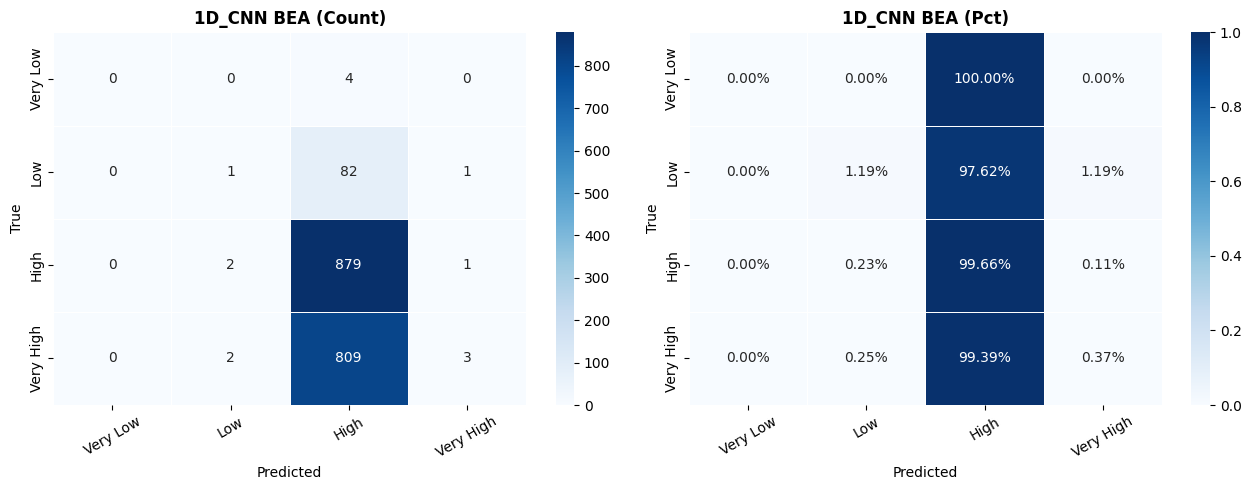


1D_CNN: Ind=47.98%  BEA=49.50%  BEM=49.38%


In [33]:
# ── Train 1D CNN ───────────────────────────────────────────────────────────
cnn_ind_eval, cnn_bea_eval, cnn_bem_eval, cnn_ind_model, cnn_models, cnn_hists = \
    train_and_eval(build_1d_cnn, '1D_CNN', cmap='Blues')

In [34]:
# ── Cell 9: 1D ResNet (Paper Baseline) ─────────────────────────────────────
def residual_block(x, filters, kernel_size=3, block_id=1):
    skip = x
    if x.shape[-1] != filters:
        skip = layers.Conv1D(filters, 1, padding='same', use_bias=False,
                             name=f'res{block_id}_proj')(x)
        skip = layers.BatchNormalization(name=f'res{block_id}_proj_bn')(skip)
    x = layers.Conv1D(filters, kernel_size, padding='same', use_bias=False,
                      name=f'res{block_id}_c1')(x)
    x = layers.BatchNormalization(name=f'res{block_id}_bn1')(x)
    x = layers.ReLU(name=f'res{block_id}_r1')(x)
    x = layers.Conv1D(filters, kernel_size, padding='same', use_bias=False,
                      name=f'res{block_id}_c2')(x)
    x = layers.BatchNormalization(name=f'res{block_id}_bn2')(x)
    x = layers.Add(name=f'res{block_id}_add')([x, skip])
    x = layers.ReLU(name=f'res{block_id}_r2')(x)
    return x

def build_1d_resnet(n_features, num_classes=4, name='1D_ResNet',
                    filters=64, n_blocks=3):
    """3-block 1D ResNet."""
    inp = Input(shape=(n_features, 1), name='input')
    x   = layers.Conv1D(filters, 1, padding='same', use_bias=False, name='stem')(inp)
    x   = layers.BatchNormalization(name='stem_bn')(x)
    x   = layers.ReLU(name='stem_relu')(x)
    for i in range(1, n_blocks + 1):
        x = residual_block(x, filters, block_id=i)
    x   = layers.GlobalAveragePooling1D(name='gap')(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return Model(inp, out, name=name)

build_1d_resnet(n_feat).summary()

Model: "1D_ResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 45, 1)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem (Conv1D)       │ (None, 45, 64)    │         64 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 45, 64)    │        256 │ stem[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_relu (ReLU)    │ (None, 45, 64)    │          0 │ stem_bn[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_c1 (Conv1D)    │ (None, 45, 64)    │     12,288 │ stem_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn1            │ (None, 45, 64)    │        256 │ res1_c1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_r1 (ReLU)      │ (None, 45, 64)    │          0 │ res1_bn1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_c2 (Conv1D)    │ (None, 45, 64)    │     12,288 │ res1_r1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_bn2            │ (None, 45, 64)    │        256 │ res1_c2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_add (Add)      │ (None, 45, 64)    │          0 │ res1_bn2[0][0],   │
│                     │                   │            │ stem_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res1_r2 (ReLU)      │ (None, 45, 64)    │          0 │ res1_add[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_c1 (Conv1D)    │ (None, 45, 64)    │     12,288 │ res1_r2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn1            │ (None, 45, 64)    │        256 │ res2_c1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_r1 (ReLU)      │ (None, 45, 64)    │          0 │ res2_bn1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_c2 (Conv1D)    │ (None, 45, 64)    │     12,288 │ res2_r1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_bn2            │ (None, 45, 64)    │        256 │ res2_c2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_add (Add)      │ (None, 45, 64)    │          0 │ res2_bn2[0][0],   │
│                     │                   │            │ res1_r2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res2_r2 (ReLU)      │ (None, 45, 64)    │          0 │ res2_add[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res3_c1 (Conv1D)    │ (None, 45, 64)    │     12,288 │ res2_r2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res3_bn1            │ (None, 45, 64)    │        256 │ res3_c1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ res3_r1 (ReLU)      │ (None, 45, 64)    │          0 │ res3_bn1[0][0]  

 Total params: 75,844 (296.27 KB)

 Trainable params: 74,948 (292.77 KB)

 Non-trainable params: 896 (3.50 KB)


[1D_ResNet]
  ✓ LOADED  1D_ResNet bag=full (weights found)
  ✓ LOADED  1D_ResNet bag=1 (weights found)
  ✓ LOADED  1D_ResNet bag=2 (weights found)
  ✓ LOADED  1D_ResNet bag=3 (weights found)
  ✓ LOADED  1D_ResNet bag=4 (weights found)
  ✓ LOADED  1D_ResNet bag=5 (weights found)
  1D_ResNet Individual                     Acc=50.56%  F1=38.25%
  1D_ResNet BEA                            Acc=49.33%  F1=33.00%
  1D_ResNet BEM                            Acc=49.38%  F1=32.74%
  (All weights loaded from checkpoint — no training curves)


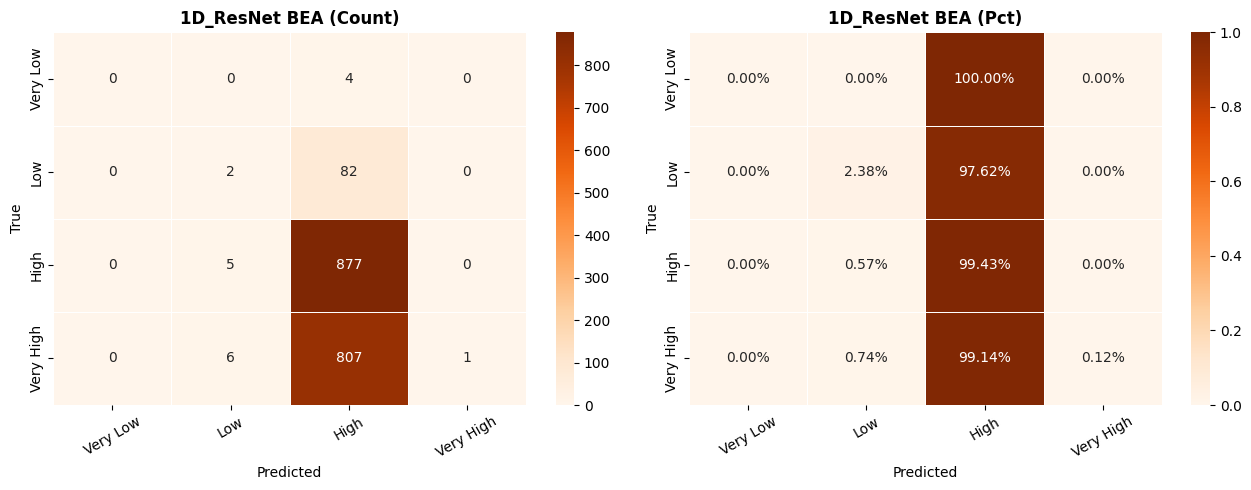


1D_ResNet: Ind=50.56%  BEA=49.33%  BEM=49.38%


In [35]:
# ── Train 1D ResNet ───────────────────────────────────────────────────────
rn_ind_eval, rn_bea_eval, rn_bem_eval, rn_ind_model, rn_models, rn_hists = \
    train_and_eval(build_1d_resnet, '1D_ResNet', cmap='Oranges')

---
## Section C — Novel CNN 1: 1D DepthwiseCNN (EfficientNet-Style)
**Key innovation:** Depthwise Separable Convolutions (MobileNet/EfficientNet).
Per-channel depthwise filter + 1×1 pointwise → ~8× fewer parameters.

In [36]:
# ── Cell 10: 1D DepthwiseCNN ───────────────────────────────────────────────
# def build_1d_depthwise_cnn(n_features, num_classes=4, name='1D_DepthwiseCNN'):
#     inp = Input(shape=(n_features, 1), name='input')
#     x   = inp
#     for i, f in enumerate([32, 64, 128], 1):
#         x = layers.SeparableConv1D(f, 3, padding='same', use_bias=False,
#                                    name=f'sep_conv{i}')(x)
#         x = layers.BatchNormalization(name=f'sep_bn{i}')(x)
#         x = layers.ReLU(name=f'sep_relu{i}')(x)
#         if i < 3:
#             x = layers.Dropout(0.1, name=f'drop{i}')(x)
#     x   = layers.GlobalAveragePooling1D(name='gap')(x)
#     x   = layers.Dense(64, activation='relu', name='fc')(x)
#     x   = layers.Dropout(0.2, name='fc_drop')(x)
#     out = layers.Dense(num_classes, activation='softmax', name='output')(x)
#     return Model(inp, out, name=name)
def build_1d_depthwise_cnn(n_features, num_classes=4, name='1D_Depthwise_Pro'):
    inp = Input(shape=(n_features, 1), name='input')

    # Initial expansion to get into a higher dimensional space
    x = layers.Conv1D(64, 3, padding='same', use_bias=False, name='stem')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)

    # Pyramid stages: [Filters, Expansion_Factor]
    configs = [(128, 4), (256, 6), (512, 6)]

    for i, (f, expand) in enumerate(configs, 1):
        # 1. Depthwise Convolution (Spatial patterns)
        x = layers.SeparableConv1D(f * expand, 3, padding='same', use_bias=False, name=f'sep{i}_dw')(x)
        x = layers.BatchNormalization()(x)
        x = layers.ReLU()(x)

        # 2. Pointwise Convolution (Channel patterns)
        x = layers.Conv1D(f, 1, padding='same', use_bias=False, name=f'sep{i}_pw')(x)
        x = layers.BatchNormalization()(x)

        # Downsample
        x = layers.MaxPooling1D(2, name=f'pool{i}')(x)

    x = layers.GlobalAveragePooling1D(name='gap')(x)

    # Stronger Classifier Head
    x = layers.Dense(512, activation='relu', name='fc1')(x)
    x = layers.Dropout(0.4, name='fc_drop1')(x)
    x = layers.Dense(256, activation='relu', name='fc2')(x)

    out = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return Model(inp, out, name=name)



_demo  = build_1d_depthwise_cnn(n_feat)
_base  = build_1d_cnn(n_feat)


print(f'DepthwiseCNN params : {_demo.count_params():,}')
print(f'Paper CNN params    : {_base.count_params():,}')
print(f'Reduction           : {(1 - _demo.count_params()/_base.count_params())*100:.1f}%')

DepthwiseCNN params : 3,468,292
Paper CNN params    : 1,951,172
Reduction           : -77.8%



[DepthwiseCNN]
  ✓ LOADED  DepthwiseCNN bag=full (weights found)
  ✓ LOADED  DepthwiseCNN bag=1 (weights found)
  ✓ LOADED  DepthwiseCNN bag=2 (weights found)
  ✓ LOADED  DepthwiseCNN bag=3 (weights found)
  ✓ LOADED  DepthwiseCNN bag=4 (weights found)
  ✓ LOADED  DepthwiseCNN bag=5 (weights found)
  DepthwiseCNN Individual                  Acc=45.07%  F1=43.13%
  DepthwiseCNN BEA                         Acc=48.26%  F1=35.26%
  DepthwiseCNN BEM                         Acc=47.65%  F1=37.65%
  (All weights loaded from checkpoint — no training curves)


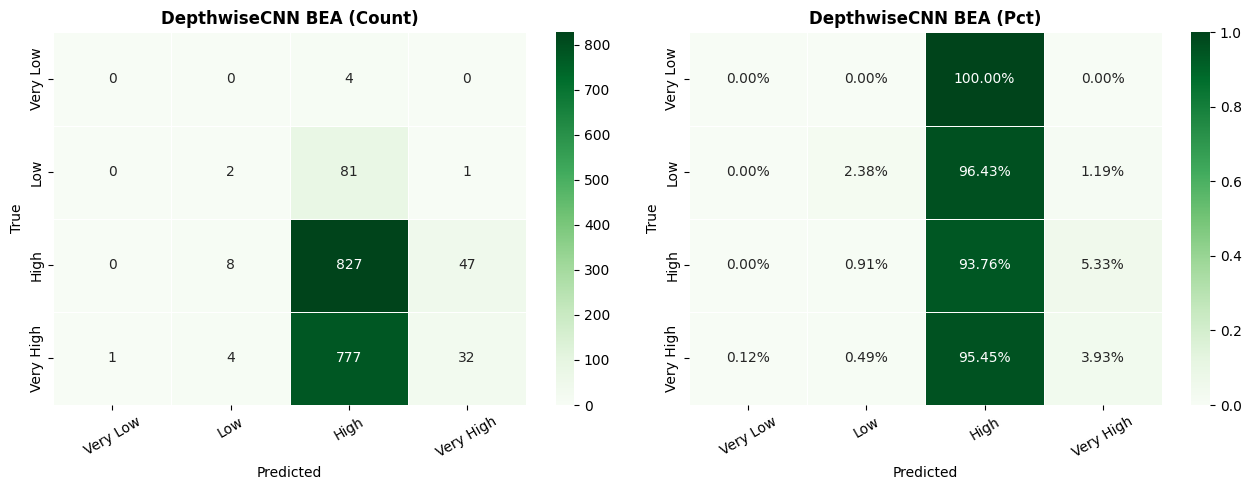


DepthwiseCNN: Ind=45.07%  BEA=48.26%  BEM=47.65%


In [37]:
# ── Train DepthwiseCNN ──────────────────────────────────────────────────────
dw_ind_eval, dw_bea_eval, dw_bem_eval, dw_ind_model, dw_models, dw_hists = \
    train_and_eval(build_1d_depthwise_cnn, 'DepthwiseCNN', cmap='Greens')

---
## Section D — Novel CNN 2: 1D DenseNet
**Key innovation:** Every layer receives feature maps from ALL previous layers via concatenation.
Maximises feature reuse and creates natural gradient highways.

In [38]:
# ── Cell 11: 1D DenseNet ───────────────────────────────────────────────────
def dense_block_1d(x, n_layers, growth_rate=32, block_id=1):
    feature_maps = [x]
    for i in range(n_layers):
        concat = layers.Concatenate(name=f'db{block_id}_cat{i}')(feature_maps)
        h = layers.BatchNormalization(name=f'db{block_id}_bn{i}')(concat)
        h = layers.ReLU(name=f'db{block_id}_relu{i}')(h)
        h = layers.Conv1D(growth_rate, 3, padding='same', use_bias=False,
                          name=f'db{block_id}_conv{i}')(h)
        h = layers.Dropout(0.1, name=f'db{block_id}_drop{i}')(h)
        feature_maps.append(h)
    return layers.Concatenate(name=f'db{block_id}_out')(feature_maps)

def transition_block_1d(x, reduction=0.5, block_id=1):
    n_filters = max(1, int(x.shape[-1] * reduction))
    x = layers.BatchNormalization(name=f'trans{block_id}_bn')(x)
    x = layers.ReLU(name=f'trans{block_id}_relu')(x)
    x = layers.Conv1D(n_filters, 1, padding='same', use_bias=False,
                      name=f'trans{block_id}_conv')(x)
    return x

def build_1d_densenet(n_features, num_classes=4, name='1D_DenseNet',
                      growth_rate=24, n_layers=4):
    inp = Input(shape=(n_features, 1), name='input')
    x   = layers.Conv1D(growth_rate * 2, 3, padding='same', use_bias=False,
                        name='init_conv')(inp)
    x   = layers.BatchNormalization(name='init_bn')(x)
    x   = layers.ReLU(name='init_relu')(x)
    for i in range(1, 4):
        x = dense_block_1d(x, n_layers, growth_rate, block_id=i)
        if i < 3:
            x = transition_block_1d(x, reduction=0.5, block_id=i)
    x   = layers.GlobalAveragePooling1D(name='gap')(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return Model(inp, out, name=name)

build_1d_densenet(n_feat).summary()

Model: "1D_DenseNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 45, 1)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init_conv (Conv1D)  │ (None, 45, 48)    │        144 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init_bn             │ (None, 45, 48)    │        192 │ init_conv[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init_relu (ReLU)    │ (None, 45, 48)    │          0 │ init_bn[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_cat0            │ (None, 45, 48)    │          0 │ init_relu[0][0]   │
│ (Concatenate)       │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_bn0             │ (None, 45, 48)    │        192 │ db1_cat0[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_relu0 (ReLU)    │ (None, 45, 48)    │          0 │ db1_bn0[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_conv0 (Conv1D)  │ (None, 45, 24)    │      3,456 │ db1_relu0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_drop0 (Dropout) │ (None, 45, 24)    │          0 │ db1_conv0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_cat1            │ (None, 45, 72)    │          0 │ init_relu[0][0],  │
│ (Concatenate)       │                   │            │ db1_drop0[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_bn1             │ (None, 45, 72)    │        288 │ db1_cat1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_relu1 (ReLU)    │ (None, 45, 72)    │          0 │ db1_bn1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_conv1 (Conv1D)  │ (None, 45, 24)    │      5,184 │ db1_relu1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_drop1 (Dropout) │ (None, 45, 24)    │          0 │ db1_conv1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_cat2            │ (None, 45, 96)    │          0 │ init_relu[0][0],  │
│ (Concatenate)       │                   │            │ db1_drop0[0][0],  │
│                     │                   │            │ db1_drop1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_bn2             │ (None, 45, 96)    │        384 │ db1_cat2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_relu2 (ReLU)    │ (None, 45, 96)    │          0 │ db1_bn2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_conv2 (Conv1D)  │ (None, 45, 24)    │      6,912 │ db1_relu2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_drop2 (Dropout) │ (None, 45, 24)    │          0 │ db1_conv2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ db1_cat3            │ (None, 45, 120)   │          0 │ init_relu[0][0],  │
│ (Concatenate)       │                   │            │ db1_drop0[0][0],  │
│                     │                   │            │ db1_drop1[0][0],

 Total params: 121,636 (475.14 KB)

 Trainable params: 118,420 (462.58 KB)

 Non-trainable params: 3,216 (12.56 KB)


[1D_DenseNet]
  ✓ LOADED  1D_DenseNet bag=full (weights found)
  ⏳ TRAINING 1D_DenseNet bag=1 ...
  1D_DenseNet bag=1 | best_val=55.00% | 6.8 min
  ⏳ TRAINING 1D_DenseNet bag=2 ...
  1D_DenseNet bag=2 | best_val=54.23% | 8.4 min
  ⏳ TRAINING 1D_DenseNet bag=3 ...
  1D_DenseNet bag=3 | best_val=48.50% | 14.2 min
  ⏳ TRAINING 1D_DenseNet bag=4 ...
  1D_DenseNet bag=4 | best_val=51.99% | 9.1 min
  ⏳ TRAINING 1D_DenseNet bag=5 ...
  1D_DenseNet bag=5 | best_val=53.04% | 10.2 min
  1D_DenseNet Individual                   Acc=48.88%  F1=41.00%
  1D_DenseNet BEA                          Acc=50.00%  F1=37.05%
  1D_DenseNet BEM                          Acc=49.55%  F1=37.77%


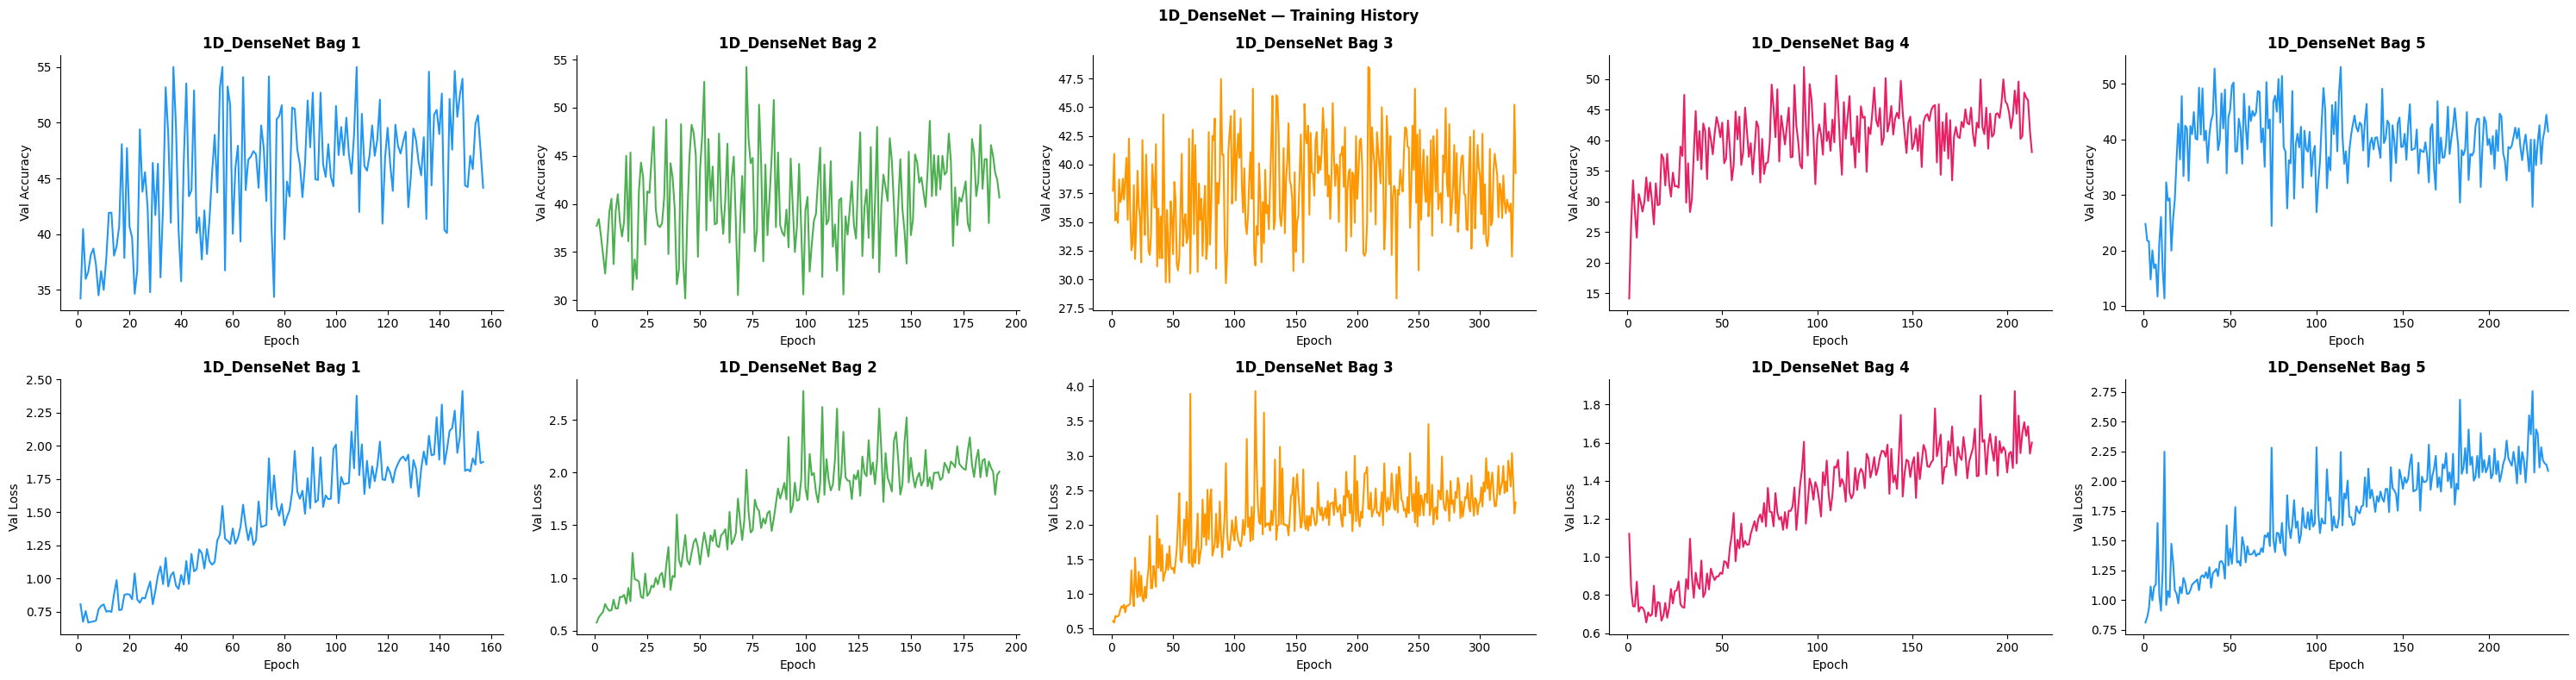

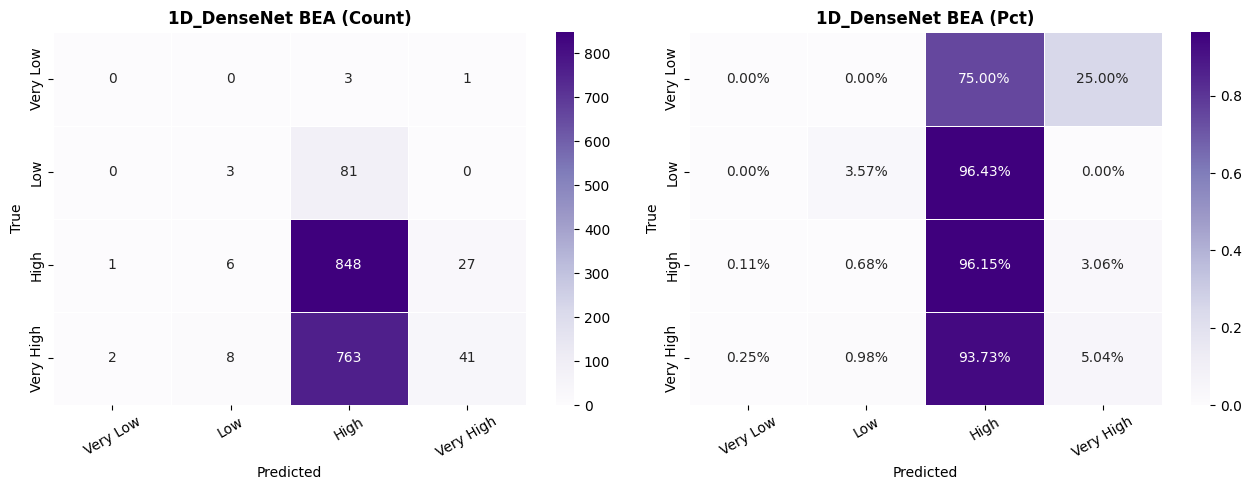


1D_DenseNet: Ind=48.88%  BEA=50.00%  BEM=49.55%


In [39]:
# ── Train DenseNet ─────────────────────────────────────────────────────────
dn_ind_eval, dn_bea_eval, dn_bem_eval, dn_ind_model, dn_models, dn_hists = \
    train_and_eval(build_1d_densenet, '1D_DenseNet', cmap='Purples')

---
## Section E — Novel CNN 3: 1D InceptionNet (Multi-Scale)
**Key innovation:** Parallel kernels k=1,3,5 capture features at multiple temporal scales.
Eye blinks (short) vs. sustained attention (long) benefit from different receptive fields.

In [40]:
# ── Cell 12: 1D InceptionNet ───────────────────────────────────────────────
def inception_module_1d(x, f1, f3, f5, fp, block_id=1):
    nm = f'inc{block_id}'
    b1 = layers.Conv1D(f1, 1, padding='same', activation='relu',
                       name=f'{nm}_b1')(x)
    b2 = layers.Conv1D(f3//2, 1, padding='same', activation='relu',
                       name=f'{nm}_b2_r')(x)
    b2 = layers.Conv1D(f3, 3, padding='same', activation='relu',
                       name=f'{nm}_b2')(b2)
    b3 = layers.Conv1D(f5//2, 1, padding='same', activation='relu',
                       name=f'{nm}_b3_r')(x)
    b3 = layers.Conv1D(f5, 5, padding='same', activation='relu',
                       name=f'{nm}_b3')(b3)
    b4 = layers.MaxPooling1D(3, strides=1, padding='same',
                             name=f'{nm}_b4_pool')(x)
    b4 = layers.Conv1D(fp, 1, padding='same', activation='relu',
                       name=f'{nm}_b4')(b4)
    out = layers.Concatenate(name=f'{nm}_cat')([b1, b2, b3, b4])
    out = layers.BatchNormalization(name=f'{nm}_bn')(out)
    return out

def build_1d_inception(n_features, num_classes=4, name='1D_InceptionNet'):
    inp = Input(shape=(n_features, 1), name='input')
    x   = layers.Conv1D(32, 3, padding='same', activation='relu',
                        name='init')(inp)
    x   = inception_module_1d(x, 16, 24, 8,  8,  block_id=1)
    x   = inception_module_1d(x, 24, 32, 16, 16, block_id=2)
    x   = inception_module_1d(x, 32, 48, 24, 24, block_id=3)
    x   = layers.GlobalAveragePooling1D(name='gap')(x)
    x   = layers.Dropout(0.3, name='drop')(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return Model(inp, out, name=name)

build_1d_inception(n_feat).summary()

Model: "1D_InceptionNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 45, 1)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init (Conv1D)       │ (None, 45, 32)    │        128 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc1_b2_r (Conv1D)  │ (None, 45, 12)    │        396 │ init[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc1_b3_r (Conv1D)  │ (None, 45, 4)     │        132 │ init[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc1_b4_pool        │ (None, 45, 32)    │          0 │ init[0][0]        │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc1_b1 (Conv1D)    │ (None, 45, 16)    │        528 │ init[0][0]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc1_b2 (Conv1D)    │ (None, 45, 24)    │        888 │ inc1_b2_r[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc1_b3 (Conv1D)    │ (None, 45, 8)     │        168 │ inc1_b3_r[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc1_b4 (Conv1D)    │ (None, 45, 8)     │        264 │ inc1_b4_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc1_cat            │ (None, 45, 56)    │          0 │ inc1_b1[0][0],    │
│ (Concatenate)       │                   │            │ inc1_b2[0][0],    │
│                     │                   │            │ inc1_b3[0][0],    │
│                     │                   │            │ inc1_b4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc1_bn             │ (None, 45, 56)    │        224 │ inc1_cat[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc2_b2_r (Conv1D)  │ (None, 45, 16)    │        912 │ inc1_bn[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc2_b3_r (Conv1D)  │ (None, 45, 8)     │        456 │ inc1_bn[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc2_b4_pool        │ (None, 45, 56)    │          0 │ inc1_bn[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc2_b1 (Conv1D)    │ (None, 45, 24)    │      1,368 │ inc1_bn[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc2_b2 (Conv1D)    │ (None, 45, 32)    │      1,568 │ inc2_b2_r[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc2_b3 (Conv1D)    │ (None, 45, 16)    │        656 │ inc2_b3_r[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc2_b4 (Conv1D)    │ (None, 45, 16)    │        912 │ inc2_b4_pool[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc2_cat            │ (None, 45, 88)    │          0 │ inc2_b1[0][0],    │
│ (Concatenate)       │                   │            │ inc2_b2[0][0],    │
│                     │                   │            │ inc2_b3[0][0],    │
│                     │                   │            │ inc2_b4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ inc2_bn             │ (None, 45, 88)    │        352 │ inc2_cat[0][0]    │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 23,136 (90.38 KB)

 Trainable params: 22,592 (88.25 KB)

 Non-trainable params: 544 (2.12 KB)


[1D_InceptionNet]
  ⏳ TRAINING 1D_InceptionNet bag=full ...
  1D_InceptionNet bag=full | best_val=44.86% | 6.2 min
  ⏳ TRAINING 1D_InceptionNet bag=1 ...
  1D_InceptionNet bag=1 | best_val=51.08% | 6.8 min
  ⏳ TRAINING 1D_InceptionNet bag=2 ...
  1D_InceptionNet bag=2 | best_val=48.22% | 6.3 min
  ⏳ TRAINING 1D_InceptionNet bag=3 ...
  1D_InceptionNet bag=3 | best_val=46.82% | 4.4 min
  ⏳ TRAINING 1D_InceptionNet bag=4 ...
  1D_InceptionNet bag=4 | best_val=46.05% | 4.8 min
  ⏳ TRAINING 1D_InceptionNet bag=5 ...
  1D_InceptionNet bag=5 | best_val=48.15% | 5.0 min
  1D_InceptionNet Individual               Acc=46.86%  F1=46.90%
  1D_InceptionNet BEA                      Acc=49.38%  F1=43.95%
  1D_InceptionNet BEM                      Acc=48.32%  F1=43.88%


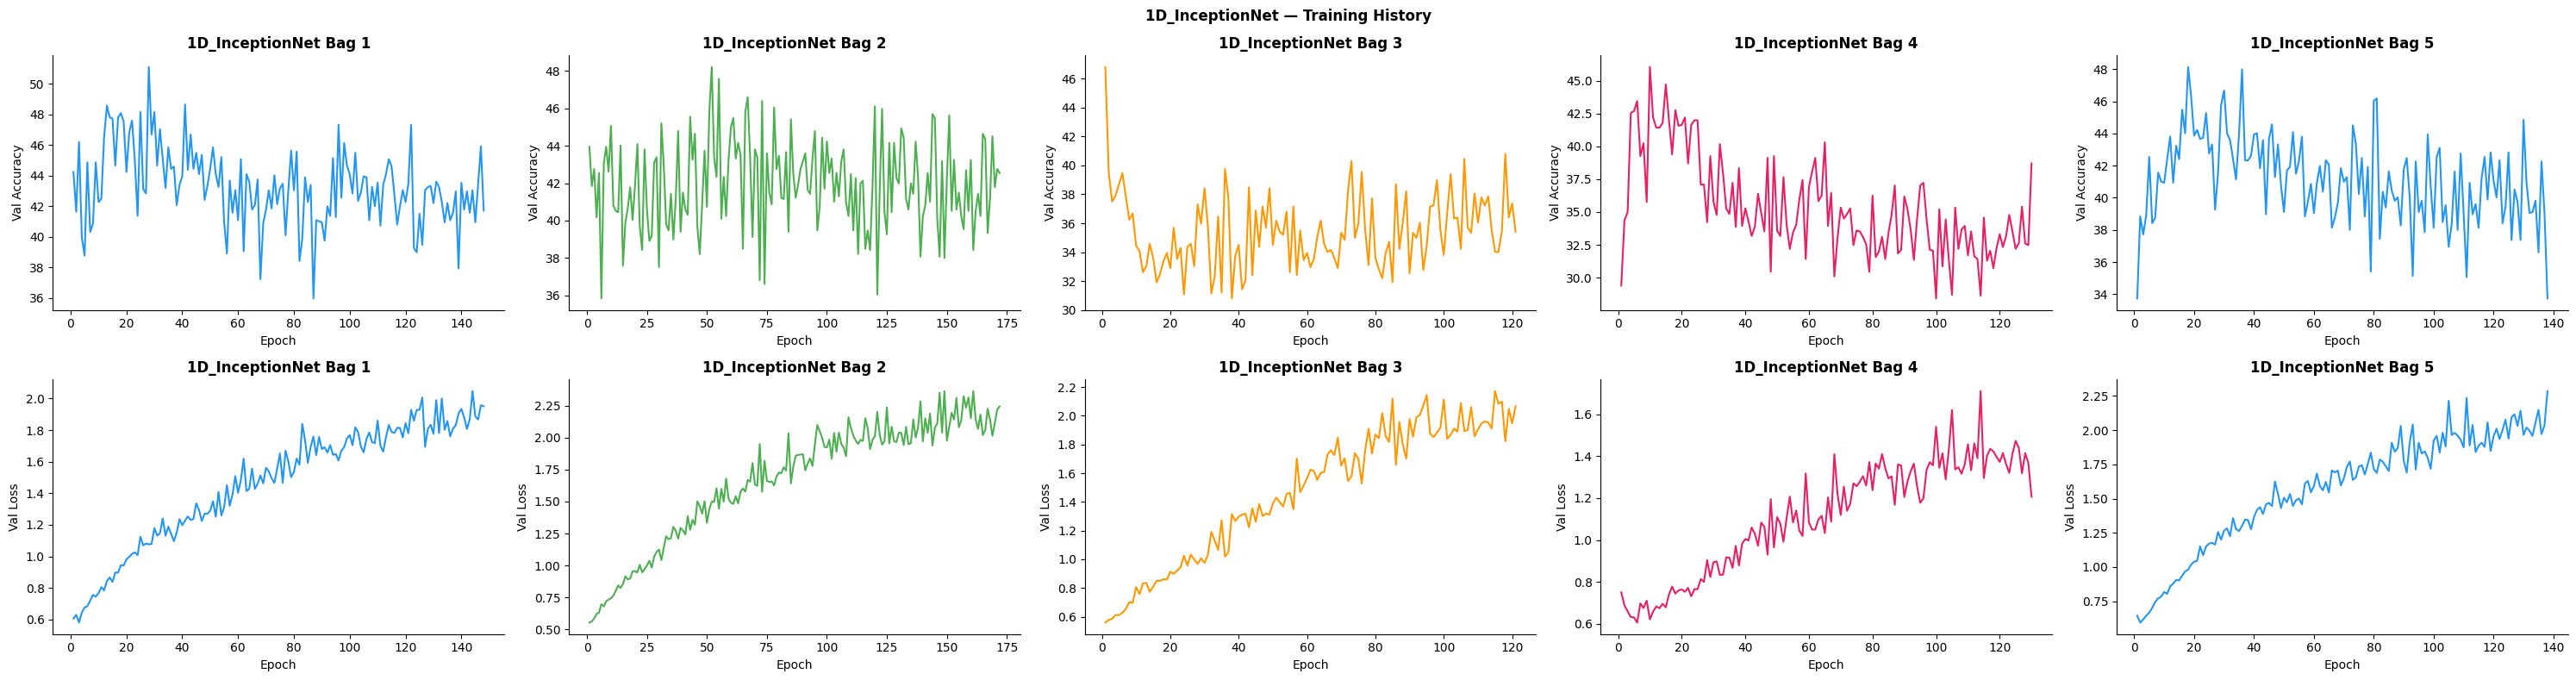

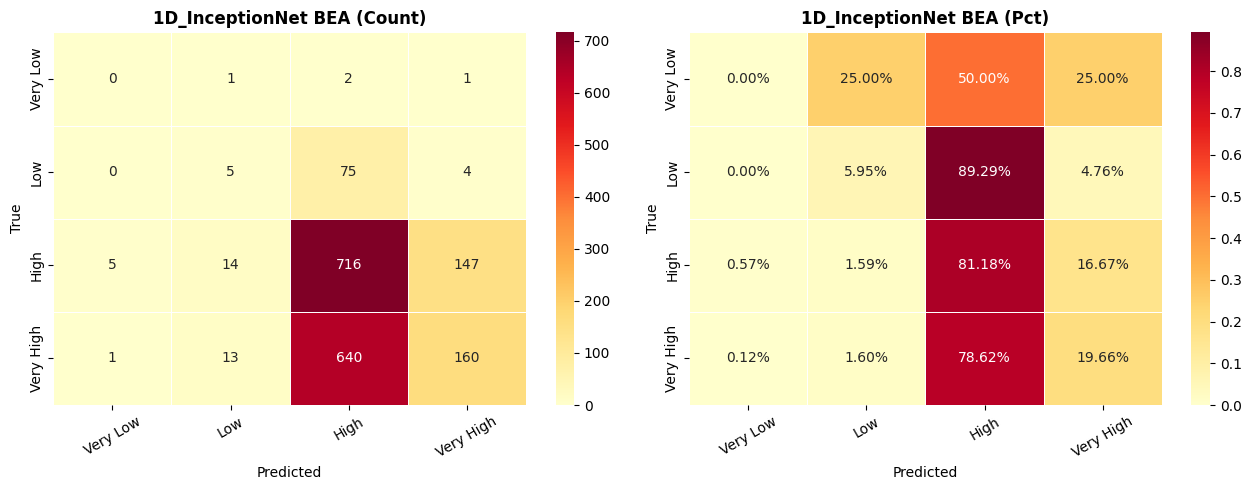


1D_InceptionNet: Ind=46.86%  BEA=49.38%  BEM=48.32%


In [41]:
# ── Train InceptionNet ─────────────────────────────────────────────────────
inc_ind_eval, inc_bea_eval, inc_bem_eval, inc_ind_model, inc_models, inc_hists = \
    train_and_eval(build_1d_inception, '1D_InceptionNet', cmap='YlOrRd')

---
## Section F — Novel CNN 4: AttentionResNet (SE Channel Attention)
**Key innovation:** Squeeze-and-Excitation (SE) channel attention after each residual block.
Learns which OpenFace AU channels matter most for engagement detection.

In [42]:
# ── Cell 13: AttentionResNet (SE) ──────────────────────────────────────────
def squeeze_excite_1d(x, ratio=4, block_id=1):
    n_ch = x.shape[-1]
    se   = layers.GlobalAveragePooling1D(name=f'se{block_id}_sq')(x)
    se   = layers.Dense(max(1, n_ch // ratio), activation='relu',
                        name=f'se{block_id}_fc1')(se)
    se   = layers.Dense(n_ch, activation='sigmoid',
                        name=f'se{block_id}_fc2')(se)
    se   = layers.Reshape((1, n_ch), name=f'se{block_id}_rs')(se)
    return layers.Multiply(name=f'se{block_id}_scale')([x, se])

def attention_residual_block(x, filters, kernel_size=3, block_id=1, se_ratio=4):
    skip = x
    if x.shape[-1] != filters:
        skip = layers.Conv1D(filters, 1, padding='same', use_bias=False,
                             name=f'ar{block_id}_proj')(x)
        skip = layers.BatchNormalization(name=f'ar{block_id}_proj_bn')(skip)
    h = layers.Conv1D(filters, kernel_size, padding='same', use_bias=False,
                      name=f'ar{block_id}_c1')(x)
    h = layers.BatchNormalization(name=f'ar{block_id}_b1')(h)
    h = layers.ReLU(name=f'ar{block_id}_r1')(h)
    h = layers.Conv1D(filters, kernel_size, padding='same', use_bias=False,
                      name=f'ar{block_id}_c2')(h)
    h = layers.BatchNormalization(name=f'ar{block_id}_b2')(h)
    h = squeeze_excite_1d(h, ratio=se_ratio, block_id=block_id)
    out = layers.Add(name=f'ar{block_id}_add')([h, skip])
    out = layers.ReLU(name=f'ar{block_id}_r2')(out)
    return out

def build_attention_resnet(n_features, num_classes=4, name='AttentionResNet',
                           filters=64, se_ratio=4):
    inp = Input(shape=(n_features, 1), name='input')
    x   = layers.Conv1D(filters, 3, padding='same', use_bias=False,
                        name='init')(inp)
    x   = layers.BatchNormalization(name='init_bn')(x)
    x   = layers.ReLU(name='init_relu')(x)
    for i in range(1, 4):
        x = attention_residual_block(x, filters, block_id=i, se_ratio=se_ratio)
    x   = layers.GlobalAveragePooling1D(name='gap')(x)
    out = layers.Dense(num_classes, activation='softmax', name='output')(x)
    return Model(inp, out, name=name)

build_attention_resnet(n_feat).summary()

Model: "AttentionResNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 45, 1)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init (Conv1D)       │ (None, 45, 64)    │        192 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init_bn             │ (None, 45, 64)    │        256 │ init[0][0]        │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ init_relu (ReLU)    │ (None, 45, 64)    │          0 │ init_bn[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ar1_c1 (Conv1D)     │ (None, 45, 64)    │     12,288 │ init_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ar1_b1              │ (None, 45, 64)    │        256 │ ar1_c1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ar1_r1 (ReLU)       │ (None, 45, 64)    │          0 │ ar1_b1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ar1_c2 (Conv1D)     │ (None, 45, 64)    │     12,288 │ ar1_r1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ar1_b2              │ (None, 45, 64)    │        256 │ ar1_c2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_sq              │ (None, 64)        │          0 │ ar1_b2[0][0]      │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_fc1 (Dense)     │ (None, 16)        │      1,040 │ se1_sq[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_fc2 (Dense)     │ (None, 64)        │      1,088 │ se1_fc1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_rs (Reshape)    │ (None, 1, 64)     │          0 │ se1_fc2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ se1_scale           │ (None, 45, 64)    │          0 │ ar1_b2[0][0],     │
│ (Multiply)          │                   │            │ se1_rs[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ar1_add (Add)       │ (None, 45, 64)    │          0 │ se1_scale[0][0],  │
│                     │                   │            │ init_relu[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ar1_r2 (ReLU)       │ (None, 45, 64)    │          0 │ ar1_add[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ar2_c1 (Conv1D)     │ (None, 45, 64)    │     12,288 │ ar1_r2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ar2_b1              │ (None, 45, 64)    │        256 │ ar2_c1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ar2_r1 (ReLU)       │ (None, 45, 64)    │          0 │ ar2_b1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ar2_c2 (Conv1D)     │ (None, 45, 64)    │     12,288 │ ar2_r1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ar2_b2              │ (None, 45, 64)    │        256 │ ar2_c2[0][0]      │
│ (BatchNormalizatio… │                   │            │                 

 Total params: 82,356 (321.70 KB)

 Trainable params: 81,460 (318.20 KB)

 Non-trainable params: 896 (3.50 KB)


[AttentionResNet]
  ✓ LOADED  AttentionResNet bag=full (weights found)
  ⏳ TRAINING AttentionResNet bag=1 ...
  AttentionResNet bag=1 | best_val=56.19% | 7.0 min
  ⏳ TRAINING AttentionResNet bag=2 ...
  AttentionResNet bag=2 | best_val=54.93% | 6.7 min
  ⏳ TRAINING AttentionResNet bag=3 ...
  AttentionResNet bag=3 | best_val=54.72% | 4.7 min
  ⏳ TRAINING AttentionResNet bag=4 ...
  AttentionResNet bag=4 | best_val=53.74% | 3.9 min
  ⏳ TRAINING AttentionResNet bag=5 ...
  AttentionResNet bag=5 | best_val=55.28% | 6.3 min
  AttentionResNet Individual               Acc=50.22%  F1=40.33%
  AttentionResNet BEA                      Acc=49.55%  F1=33.84%
  AttentionResNet BEM                      Acc=49.61%  F1=33.96%


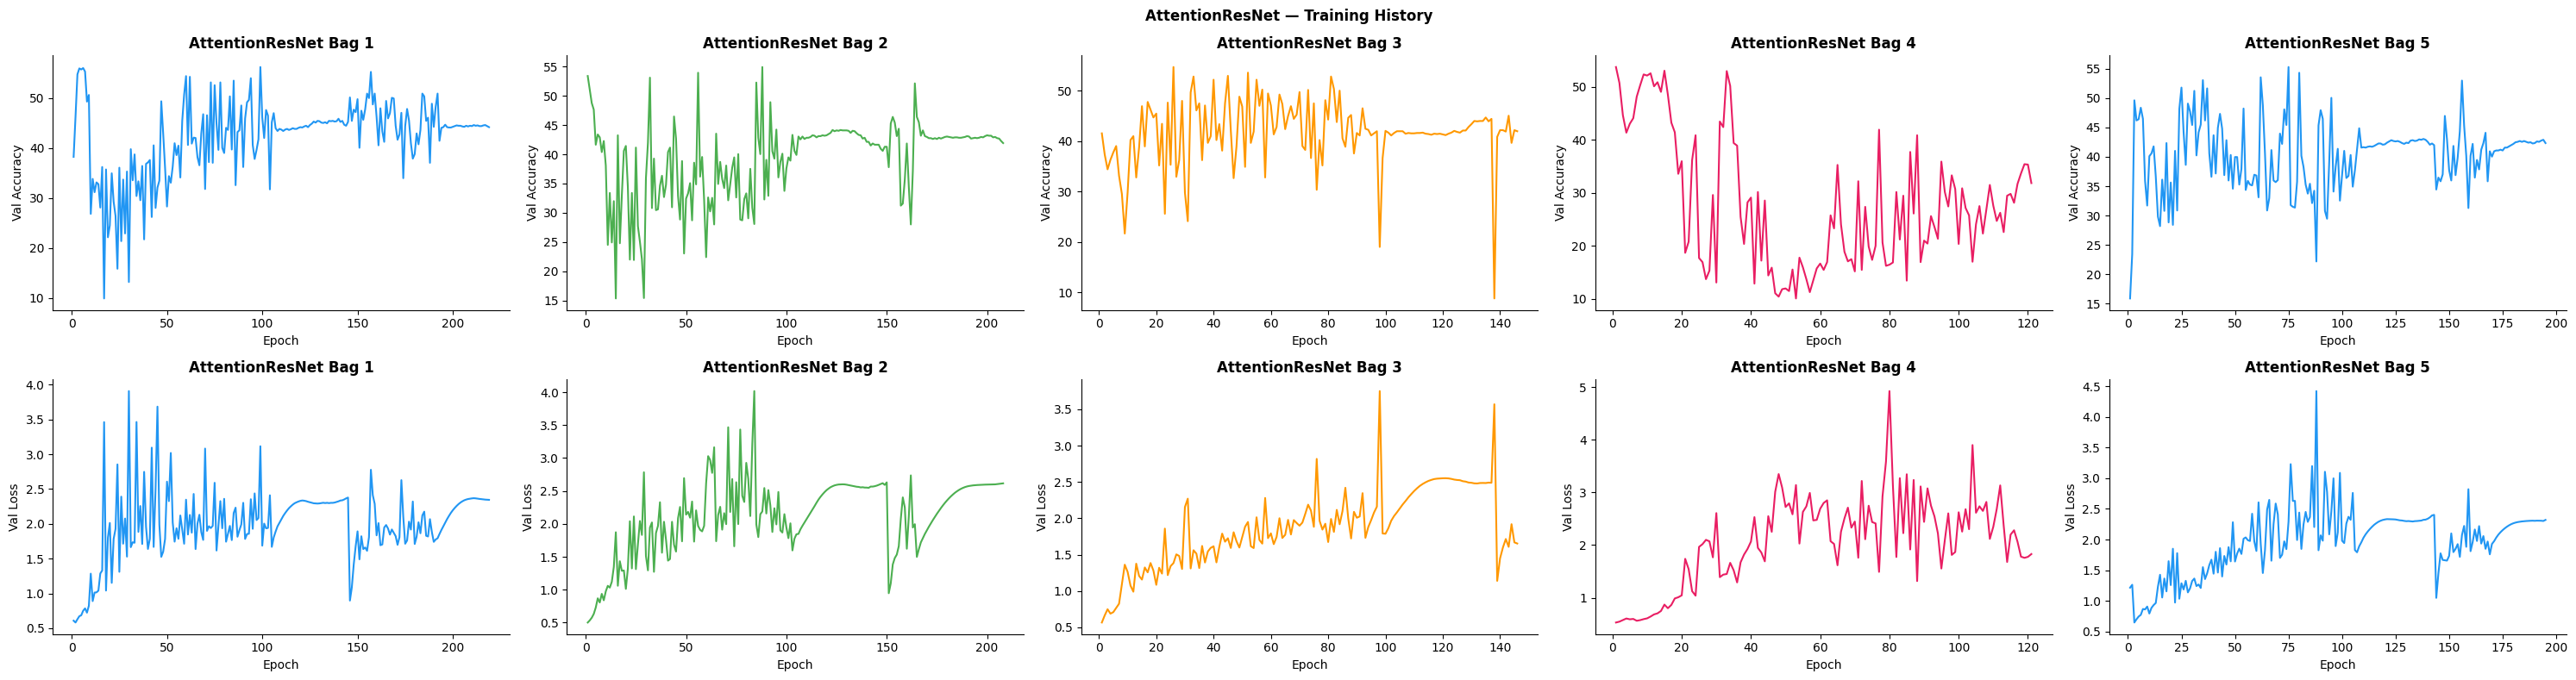

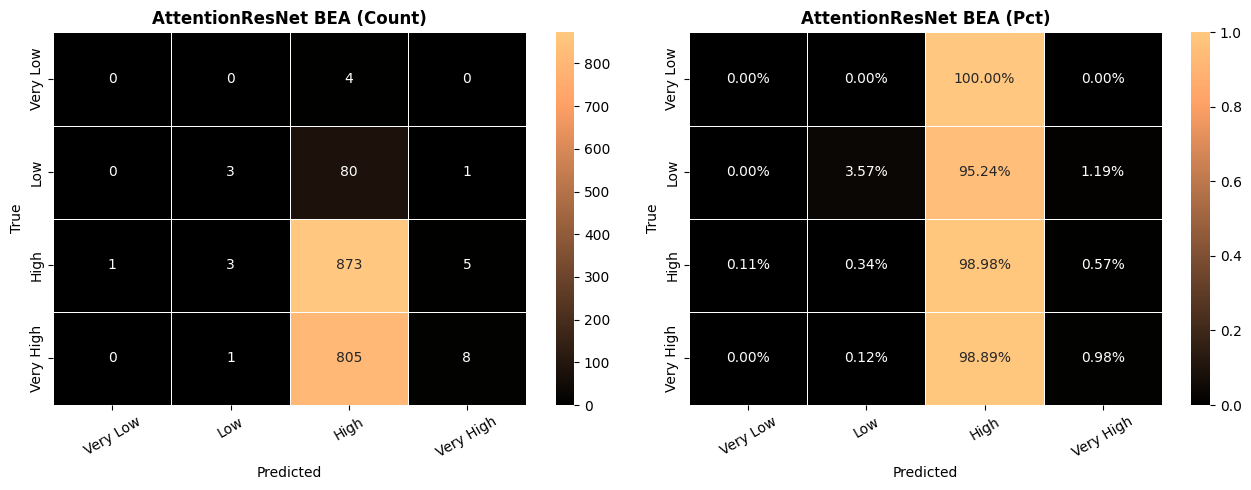


AttentionResNet: Ind=50.22%  BEA=49.55%  BEM=49.61%


In [43]:
# ── Train AttentionResNet ──────────────────────────────────────────────────
attn_ind_eval, attn_bea_eval, attn_bem_eval, \
    attn_ind_model, attn_models, attn_hists = \
    train_and_eval(build_attention_resnet, 'AttentionResNet', cmap='copper')

---
## Section G — Encoder-Decoder 1: Autoencoder Classifier
**Key idea:** Dual-head model — classification + reconstruction.
Reconstruction path regularises the encoder when engagement labels are noisy (DAiSEE ~73% inter-rater agreement).

```
Input (F,1) ──→ Encoder ──→ Bottleneck ──→ Decoder ──→ Reconstructed Input
                    ↓
              Classifier head ──→ Engagement class (4)
```
**Loss:** `L = Focal(class) + 0.3 × MSE(recon)`

In [46]:
# ── Cell 14: Autoencoder Classifier ────────────────────────────────────────
def build_autoencoder_classifier(n_features, num_classes=4,
                                  name='AutoEncoderClassifier',
                                  latent_dim=16, recon_weight=0.3):
    inp = Input(shape=(n_features, 1), name='input')

    x = layers.Conv1D(32,  3, padding='same', activation='relu', name='enc_c1')(inp)
    x = layers.BatchNormalization(name='enc_bn1')(x)
    x = layers.Conv1D(64,  3, padding='same', activation='relu', name='enc_c2')(x)
    x = layers.BatchNormalization(name='enc_bn2')(x)
    x = layers.Conv1D(128, 3, padding='same', activation='relu', name='enc_c3')(x)
    x = layers.BatchNormalization(name='enc_bn3')(x)

    x_gap      = layers.GlobalAveragePooling1D(name='enc_gap')(x)
    bottleneck = layers.Dense(latent_dim, activation='relu', name='bottleneck')(x_gap)

    clf     = layers.Dropout(0.3, name='clf_drop')(bottleneck)
    clf     = layers.Dense(32, activation='relu', name='clf_fc')(clf)
    clf_out = layers.Dense(num_classes, activation='softmax', name='class_output')(clf)

    dec       = layers.Dense(n_features * 64, activation='relu', name='dec_expand')(bottleneck)
    dec       = layers.Reshape((n_features, 64), name='dec_reshape')(dec)
    dec       = layers.Conv1D(64, 3, padding='same', activation='relu', name='dec_c1')(dec)
    dec       = layers.Conv1D(32, 3, padding='same', activation='relu', name='dec_c2')(dec)
    recon_out = layers.Conv1D(1,  3, padding='same', activation='linear', name='recon_output')(dec)

    model = Model(inputs=inp, outputs=[clf_out, recon_out], name=name)
    model.compile(
        optimizer=Adam(LEARNING_RATE),
        loss={'class_output': focal_loss(), 'recon_output': 'mse'},
        loss_weights={'class_output': 1.0, 'recon_output': recon_weight},
        metrics={'class_output': 'accuracy'}
    )
    return model

_ae = build_autoencoder_classifier(n_feat)
_ae.summary()
print(f'\nAutoencoder params: {_ae.count_params():,}')

Model: "AutoEncoderClassifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 45, 1)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_c1 (Conv1D)     │ (None, 45, 32)    │        128 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bn1             │ (None, 45, 32)    │        128 │ enc_c1[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_c2 (Conv1D)     │ (None, 45, 64)    │      6,208 │ enc_bn1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bn2             │ (None, 45, 64)    │        256 │ enc_c2[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_c3 (Conv1D)     │ (None, 45, 128)   │     24,704 │ enc_bn2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_bn3             │ (None, 45, 128)   │        512 │ enc_c3[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc_gap             │ (None, 128)       │          0 │ enc_bn3[0][0]     │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck (Dense)  │ (None, 16)        │      2,064 │ enc_gap[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_expand (Dense)  │ (None, 2880)      │     48,960 │ bottleneck[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_reshape         │ (None, 45, 64)    │          0 │ dec_expand[0][0]  │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clf_drop (Dropout)  │ (None, 16)        │          0 │ bottleneck[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_c1 (Conv1D)     │ (None, 45, 64)    │     12,352 │ dec_reshape[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ clf_fc (Dense)      │ (None, 32)        │        544 │ clf_drop[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec_c2 (Conv1D)     │ (None, 45, 32)    │      6,176 │ dec_c1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_output        │ (None, 4)         │        132 │ clf_fc[0][0]      │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ recon_output        │ (None, 45, 1)     │         97 │ dec_c2[0][0]      │
│ (Conv1D)            │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 102,261 (399.46 KB)

 Trainable params: 101,813 (397.71 KB)

 Non-trainable params: 448 (1.75 KB)


Autoencoder params: 102,261


[AutoEncoder] Individual
   Loaded: AEClassifier_bagfull_best.weights.h5

[AutoEncoder] Bagging Ensemble
  Bag 1/5
   Loaded: AEClassifier_bag1_best.weights.h5
  Bag 2/5
   Loaded: AEClassifier_bag2_best.weights.h5
  Bag 3/5
   Loaded: AEClassifier_bag3_best.weights.h5
  Bag 4/5
   Loaded: AEClassifier_bag4_best.weights.h5
  Bag 5/5
   Loaded: AEClassifier_bag5_best.weights.h5
  AEClassifier Individual                  Acc=43.89%  F1=40.93%
  AEClassifier BEA                         Acc=49.83%  F1=49.01%
  AEClassifier BEM                         Acc=47.37%  F1=47.03%
  (All weights loaded — no training curves)


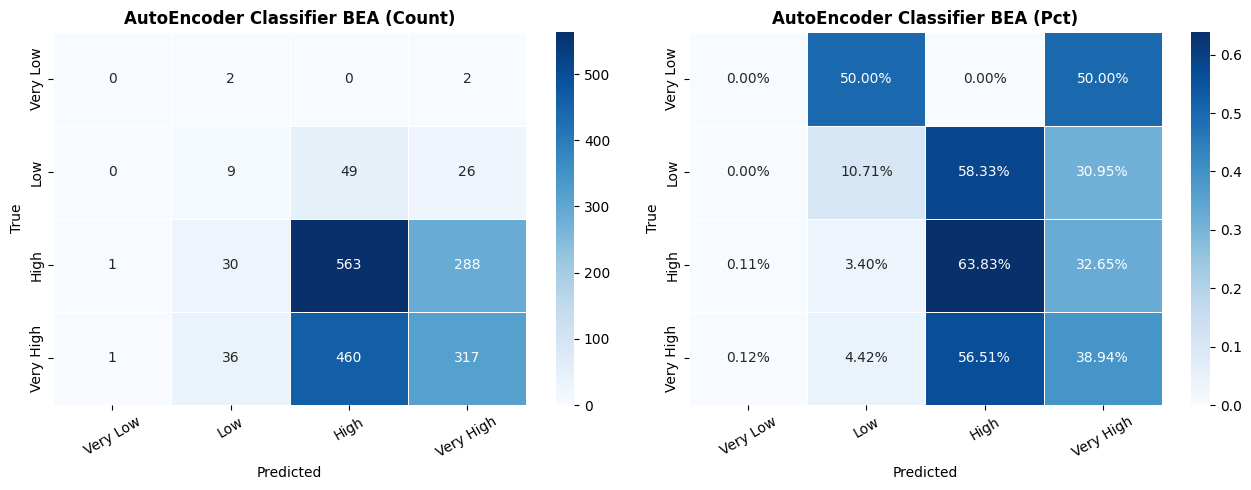


AEClassifier: Ind=43.89%  BEA=49.83%  BEM=47.37%


In [56]:
# ── Cell 15: Train Autoencoder Classifier (with checkpoint resume) ──────────

def train_autoencoder(model, X_tr_, y_tr_, X_val_, y_val_,
                      batch_size=BATCH_SIZE, name='AEClassifier', bag='full'):
    yc_tr  = to_categorical(y_tr_,  NUM_CLASSES)
    yc_val = to_categorical(y_val_, NUM_CLASSES)
    X_mix, y_mix = mixup_batch(X_tr_, yc_tr)
    t0   = time.time()
    hist = model.fit(
        X_mix, {'class_output': y_mix, 'recon_output': X_mix},
        validation_data=(X_val_, {'class_output': yc_val, 'recon_output': X_val_}),
        epochs=EPOCHS, batch_size=batch_size,
        callbacks=get_callbacks(name, bag), verbose=0)
    elapsed  = (time.time() - t0) / 60
    key      = 'val_class_output_accuracy'
    best_val = max(hist.history.get(key, [0])) * 100
    print(f'  {name} bag={bag} | best_val={best_val:.2f}% | {elapsed:.1f} min')
    return hist, elapsed

def load_or_train_ae(build_fn, name, X_tr_, y_tr_, X_val_, y_val_, bag='full'):
    weight_path = os.path.join(MODEL_DIR, f'{name}_bag{bag}_best.weights.h5')
    model = build_fn(n_feat, name=f'{name}_bag{bag}')
    if os.path.exists(weight_path):
        model.load_weights(weight_path)
        print(f'   Loaded: {os.path.basename(weight_path)}')
        return model, None
    print(f'   Training: {name} bag={bag}')
    hist, _ = train_autoencoder(model, X_tr_, y_tr_, X_val_, y_val_,
                                name=name, bag=bag)
    return model, hist

def ae_predict(model, X):
    clf_out, _ = model.predict(X, verbose=0)
    return clf_out

def ae_tta_predict(model, X, n_runs=TTA_RUNS, noise_std=0.01):
    probs = []
    for _ in range(n_runs):
        X_aug = X + np.random.normal(0, noise_std, X.shape).astype(np.float32)
        p, _  = model.predict(X_aug, verbose=0)
        probs.append(p)
    return np.stack(probs).mean(0)

# Individual
print('='*60)
print('[AutoEncoder] Individual')
print('='*60)
ae_ind_model, ae_ind_hist = load_or_train_ae(
    build_autoencoder_classifier, 'AEClassifier',
    X_tr_c, y_tr, X_val_c, y_val_raw, bag='full')

# Bagging
print('\n[AutoEncoder] Bagging Ensemble')
ae_bag_models, ae_bag_hists = [], []
for b, bag in enumerate(bags):
    print(f'  Bag {b+1}/{N_BAGS}')
    m, h = load_or_train_ae(
        build_autoencoder_classifier, 'AEClassifier',
        bag['X'], bag['y'], X_val_c, y_val_raw, bag=b+1)
    ae_bag_models.append(m)
    ae_bag_hists.append(h)

# Evaluate
ae_ind_probs = ae_tta_predict(ae_ind_model, X_te_c)
ae_ind_preds = np.argmax(ae_ind_probs, 1)
ae_ind_eval  = compute_metrics(y_test_raw, ae_ind_preds, label='AEClassifier Individual')

ae_bea_probs = np.stack([ae_tta_predict(m, X_te_c) for m in ae_bag_models]).mean(0)
ae_bem_probs = np.stack([ae_tta_predict(m, X_te_c) for m in ae_bag_models]).max(0)
ae_bea_preds = np.argmax(ae_bea_probs, 1)
ae_bem_preds = np.argmax(ae_bem_probs, 1)
ae_bea_eval  = compute_metrics(y_test_raw, ae_bea_preds, label='AEClassifier BEA')
ae_bem_eval  = compute_metrics(y_test_raw, ae_bem_preds, label='AEClassifier BEM')

trained_hists = [h for h in ae_bag_hists if h is not None]
if trained_hists:
    plot_training_curve(trained_hists, 'AEClassifier')
else:
    print('  (All weights loaded — no training curves)')

plot_confusion(y_test_raw, ae_bea_preds, 'AutoEncoder Classifier BEA', cmap='Blues')
print(f'\nAEClassifier: Ind={ae_ind_eval["accuracy"]:.2f}%  '
      f'BEA={ae_bea_eval["accuracy"]:.2f}%  BEM={ae_bem_eval["accuracy"]:.2f}%')

In [72]:


# ── AFTER (new) ─────────────────────────────────────────────────────────────
ae_ind_eval = compute_metrics(y_test_raw, ae_ind_preds,
                              label='AEClassifier Individual', y_prob=ae_ind_probs)
ae_bea_eval = compute_metrics(y_test_raw, ae_bea_preds,
                              label='AEClassifier BEA',        y_prob=ae_bea_probs)
ae_bem_eval = compute_metrics(y_test_raw, ae_bem_preds,
                              label='AEClassifier BEM',        y_prob=ae_bem_probs)

  AEClassifier Individual                   Acc=43.89%  F1=40.93%
  AEClassifier BEA                          Acc=49.83%  F1=49.01%
  AEClassifier BEM                          Acc=47.37%  F1=47.03%
  AEClassifier Individual                   Acc=43.89%  F1=40.93%  AUC=52.40%
  AEClassifier BEA                          Acc=49.83%  F1=49.01%  AUC=53.27%
  AEClassifier BEM                          Acc=47.37%  F1=47.03%  AUC=53.94%


---
## Section H — Encoder-Decoder 2: U-Net Style with Skip Connections
**Key innovation:** Skip connections directly link encoder and decoder layers.
Bottleneck focuses on high-level engagement semantics; skips preserve fine-grained detail.

```
Enc Block 1 ──────────────────────────→ Skip → Dec Block 3
    ↓                                              ↑
Enc Block 2 ──────────────→ Skip → Dec Block 2    ↑
    ↓                                   ↑          ↑
Enc Block 3 ──→ Bottleneck → ─────────────────────┘
```

In [47]:
# ── Cell 16: 1D U-Net Style Encoder-Decoder Classifier ──────────────────────
def build_unet_classifier(n_features, num_classes=4, name='UNetClassifier',
                          base_filters=32):
    inp = Input(shape=(n_features, 1), name='input')

    # Encoder Block 1
    e1    = layers.Conv1D(base_filters, 3, padding='same', use_bias=False, name='enc1_c1')(inp)
    e1    = layers.BatchNormalization(name='enc1_bn1')(e1)
    e1    = layers.ReLU(name='enc1_r1')(e1)
    e1    = layers.Conv1D(base_filters, 3, padding='same', use_bias=False, name='enc1_c2')(e1)
    e1    = layers.BatchNormalization(name='enc1_bn2')(e1)
    skip1 = layers.ReLU(name='skip1')(e1)

    # Encoder Block 2
    e2    = layers.Conv1D(base_filters*2, 3, padding='same', use_bias=False, name='enc2_c1')(skip1)
    e2    = layers.BatchNormalization(name='enc2_bn1')(e2)
    e2    = layers.ReLU(name='enc2_r1')(e2)
    e2    = layers.Conv1D(base_filters*2, 3, padding='same', use_bias=False, name='enc2_c2')(e2)
    e2    = layers.BatchNormalization(name='enc2_bn2')(e2)
    skip2 = layers.ReLU(name='skip2')(e2)

    # Encoder Block 3 (bottleneck)
    e3         = layers.Conv1D(base_filters*4, 3, padding='same', use_bias=False, name='enc3_c1')(skip2)
    e3         = layers.BatchNormalization(name='enc3_bn1')(e3)
    e3         = layers.ReLU(name='enc3_r1')(e3)
    e3         = layers.Conv1D(base_filters*4, 3, padding='same', use_bias=False, name='enc3_c2')(e3)
    e3         = layers.BatchNormalization(name='enc3_bn2')(e3)
    bottleneck = layers.ReLU(name='bottleneck')(e3)

    # Classification head
    clf     = layers.GlobalAveragePooling1D(name='clf_gap')(bottleneck)
    clf     = layers.Dense(64, activation='relu', name='clf_fc1')(clf)
    clf     = layers.Dropout(0.3, name='clf_drop')(clf)
    clf_out = layers.Dense(num_classes, activation='softmax', name='class_output')(clf)

    # Decoder with skip connections
    d1 = layers.Conv1D(base_filters*2, 3, padding='same', use_bias=False, name='dec1_c1')(bottleneck)
    d1 = layers.BatchNormalization(name='dec1_bn1')(d1)
    d1 = layers.ReLU(name='dec1_r1')(d1)
    d1 = layers.Concatenate(name='cat_skip2')([d1, skip2])
    d1 = layers.Conv1D(base_filters*2, 3, padding='same', use_bias=False, name='dec1_c2')(d1)
    d1 = layers.BatchNormalization(name='dec1_bn2')(d1)
    d1 = layers.ReLU(name='dec1_r2')(d1)

    d2        = layers.Conv1D(base_filters, 3, padding='same', use_bias=False, name='dec2_c1')(d1)
    d2        = layers.BatchNormalization(name='dec2_bn1')(d2)
    d2        = layers.ReLU(name='dec2_r1')(d2)
    d2        = layers.Concatenate(name='cat_skip1')([d2, skip1])
    d2        = layers.Conv1D(base_filters, 3, padding='same', use_bias=False, name='dec2_c2')(d2)
    d2        = layers.BatchNormalization(name='dec2_bn2')(d2)
    d2        = layers.ReLU(name='dec2_r2')(d2)
    recon_out = layers.Conv1D(1, 1, padding='same', activation='linear', name='recon_output')(d2)

    model = Model(inputs=inp, outputs=[clf_out, recon_out], name=name)
    model.compile(
        optimizer=Adam(LEARNING_RATE),
        loss={'class_output': focal_loss(), 'recon_output': 'mse'},
        loss_weights={'class_output': 1.0, 'recon_output': 0.3},
        metrics={'class_output': 'accuracy'}
    )
    return model

_unet = build_unet_classifier(n_feat)
_unet.summary()
print(f'\nU-Net params: {_unet.count_params():,}')

Model: "UNetClassifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 45, 1)     │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_c1 (Conv1D)    │ (None, 45, 32)    │         96 │ input[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn1            │ (None, 45, 32)    │        128 │ enc1_c1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_r1 (ReLU)      │ (None, 45, 32)    │          0 │ enc1_bn1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_c2 (Conv1D)    │ (None, 45, 32)    │      3,072 │ enc1_r1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc1_bn2            │ (None, 45, 32)    │        128 │ enc1_c2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip1 (ReLU)        │ (None, 45, 32)    │          0 │ enc1_bn2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_c1 (Conv1D)    │ (None, 45, 64)    │      6,144 │ skip1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn1            │ (None, 45, 64)    │        256 │ enc2_c1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_r1 (ReLU)      │ (None, 45, 64)    │          0 │ enc2_bn1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_c2 (Conv1D)    │ (None, 45, 64)    │     12,288 │ enc2_r1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc2_bn2            │ (None, 45, 64)    │        256 │ enc2_c2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ skip2 (ReLU)        │ (None, 45, 64)    │          0 │ enc2_bn2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_c1 (Conv1D)    │ (None, 45, 128)   │     24,576 │ skip2[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn1            │ (None, 45, 128)   │        512 │ enc3_c1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_r1 (ReLU)      │ (None, 45, 128)   │          0 │ enc3_bn1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_c2 (Conv1D)    │ (None, 45, 128)   │     49,152 │ enc3_r1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ enc3_bn2            │ (None, 45, 128)   │        512 │ enc3_c2[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bottleneck (ReLU)   │ (None, 45, 128)   │          0 │ enc3_bn2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec1_c1 (Conv1D)    │ (None, 45, 64)    │     24,576 │ bottleneck[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dec1_bn1            │ (None, 45, 64)    │        256 │ dec1_c1[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 167,877 (655.77 KB)

 Trainable params: 166,597 (650.77 KB)

 Non-trainable params: 1,280 (5.00 KB)


U-Net params: 167,877


[UNet] Individual
   Loaded: UNetClassifier_bagfull_best.weights.h5

[UNet] Bagging Ensemble
  Bag 1/5
   Loaded: UNetClassifier_bag1_best.weights.h5
  Bag 2/5
   Loaded: UNetClassifier_bag2_best.weights.h5
  Bag 3/5
   Loaded: UNetClassifier_bag3_best.weights.h5
  Bag 4/5
   Loaded: UNetClassifier_bag4_best.weights.h5
  Bag 5/5
   Loaded: UNetClassifier_bag5_best.weights.h5
  UNetClassifier Individual                Acc=48.60%  F1=48.45%
  UNetClassifier BEA                       Acc=45.12%  F1=43.95%
  UNetClassifier BEM                       Acc=43.89%  F1=44.17%
  (All weights loaded — no training curves)


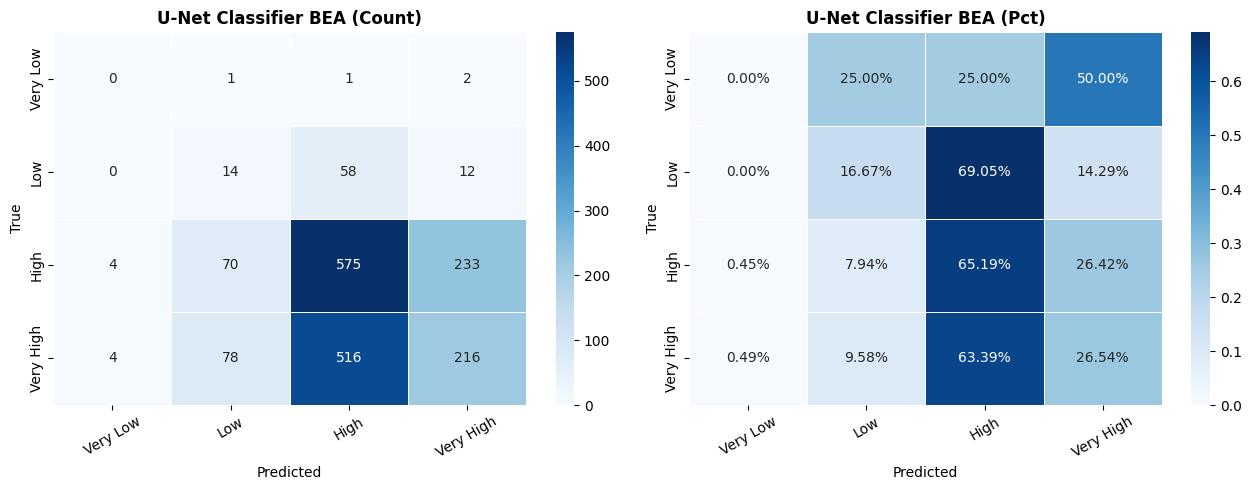


U-Net: Ind=48.60%  BEA=45.12%  BEM=43.89%


In [53]:
# ── Cell 17: Train U-Net Classifier (with checkpoint resume) ────────────────

def load_or_train_unet(build_fn, name, X_tr_, y_tr_, X_val_, y_val_, bag='full'):
    weight_path = os.path.join(MODEL_DIR, f'{name}_bag{bag}_best.weights.h5')
    model = build_fn(n_feat, name=f'{name}_bag{bag}')
    if os.path.exists(weight_path):
        model.load_weights(weight_path)
        print(f'   Loaded: {os.path.basename(weight_path)}')
        return model, None
    print(f'   Training: {name} bag={bag}')
    hist, _ = train_autoencoder(model, X_tr_, y_tr_, X_val_, y_val_,
                                name=name, bag=bag)
    return model, hist

def unet_predict(model, X):
    clf_out, _ = model.predict(X, verbose=0)
    return clf_out

def unet_tta_predict(model, X, n_runs=TTA_RUNS, noise_std=0.01):
    probs = []
    for _ in range(n_runs):
        X_aug = X + np.random.normal(0, noise_std, X.shape).astype(np.float32)
        p, _  = model.predict(X_aug, verbose=0)
        probs.append(p)
    return np.stack(probs).mean(0)

# Individual
print('='*60)
print('[UNet] Individual')
print('='*60)
unet_ind_model, unet_ind_hist = load_or_train_unet(
    build_unet_classifier, 'UNetClassifier',
    X_tr_c, y_tr, X_val_c, y_val_raw, bag='full')

# Bagging
print('\n[UNet] Bagging Ensemble')
unet_bag_models, unet_bag_hists = [], []
for b, bag in enumerate(bags):
    print(f'  Bag {b+1}/{N_BAGS}')
    m, h = load_or_train_unet(
        build_unet_classifier, 'UNetClassifier',
        bag['X'], bag['y'], X_val_c, y_val_raw, bag=b+1)
    unet_bag_models.append(m)
    unet_bag_hists.append(h)

# Evaluate
unet_ind_probs = unet_tta_predict(unet_ind_model, X_te_c)
unet_ind_preds = np.argmax(unet_ind_probs, 1)
unet_ind_eval  = compute_metrics(y_test_raw, unet_ind_preds, label='UNetClassifier Individual')

unet_bea_probs = np.stack([unet_tta_predict(m, X_te_c) for m in unet_bag_models]).mean(0)
unet_bem_probs = np.stack([unet_tta_predict(m, X_te_c) for m in unet_bag_models]).max(0)
unet_bea_preds = np.argmax(unet_bea_probs, 1)
unet_bem_preds = np.argmax(unet_bem_probs, 1)
unet_bea_eval  = compute_metrics(y_test_raw, unet_bea_preds, label='UNetClassifier BEA')
unet_bem_eval  = compute_metrics(y_test_raw, unet_bem_preds, label='UNetClassifier BEM')

trained_hists = [h for h in unet_bag_hists if h is not None]
if trained_hists:
    plot_training_curve(trained_hists, 'UNetClassifier')
else:
    print('  (All weights loaded — no training curves)')

plot_confusion(y_test_raw, unet_bea_preds, 'U-Net Classifier BEA', cmap='Blues')
print(f'\nU-Net: Ind={unet_ind_eval["accuracy"]:.2f}%  '
      f'BEA={unet_bea_eval["accuracy"]:.2f}%  BEM={unet_bem_eval["accuracy"]:.2f}%')

In [73]:
# ── AFTER (new) ─────────────────────────────────────────────────────────────
unet_ind_eval = compute_metrics(y_test_raw, unet_ind_preds,
                                label='UNetClassifier Individual', y_prob=unet_ind_probs)
unet_bea_eval = compute_metrics(y_test_raw, unet_bea_preds,
                                label='UNetClassifier BEA',        y_prob=unet_bea_probs)
unet_bem_eval = compute_metrics(y_test_raw, unet_bem_preds,
                                label='UNetClassifier BEM',        y_prob=unet_bem_probs)

  UNetClassifier Individual                 Acc=48.60%  F1=48.45%  AUC=51.79%
  UNetClassifier BEA                        Acc=45.12%  F1=43.95%  AUC=51.24%
  UNetClassifier BEM                        Acc=43.89%  F1=44.17%  AUC=50.43%


---
## Section I — Stacking Ensemble (Meta-Learner)
**Beyond bagging:** Meta-learner trained on all 8 base models' probability outputs.
Learns which architecture to trust for each engagement pattern.

Building Stacking Ensemble...

  1D_CNN            : val shape (1429, 4)
  1D_ResNet         : val shape (1429, 4)
  DepthwiseCNN      : val shape (1429, 4)
  1D_DenseNet       : val shape (1429, 4)
  1D_InceptionNet   : val shape (1429, 4)
  AttentionResNet   : val shape (1429, 4)
  AEClassifier      : val shape (1429, 4)
  UNetClassifier    : val shape (1429, 4)

Meta-train: (1429, 32)  Meta-test: (1784, 32)
  Stacking (LR)                            Acc=50.06%  F1=37.19%
  Stacking (MLP)                           Acc=49.44%  F1=32.71%


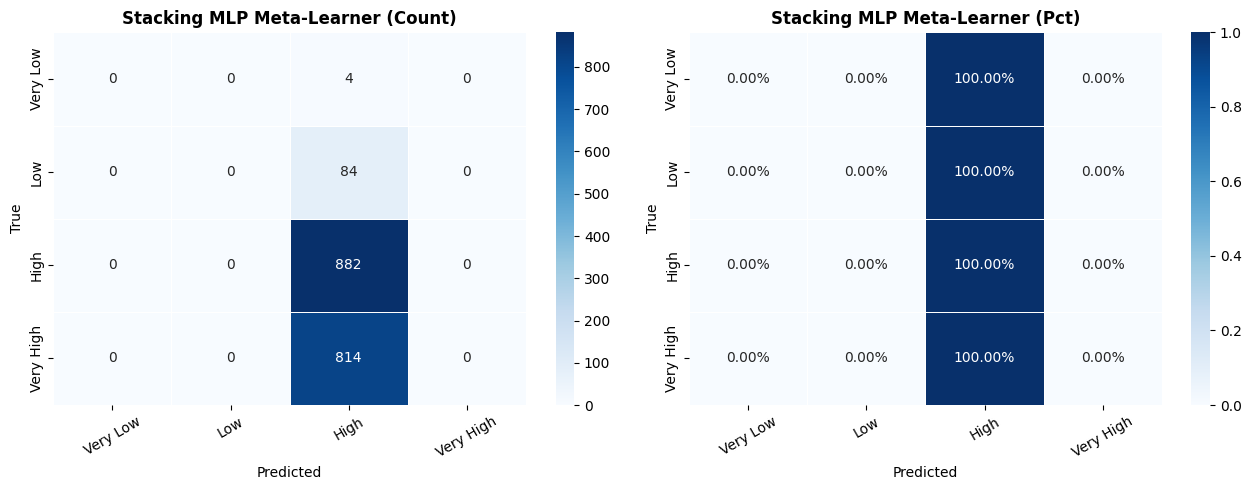


Stacking LR  Accuracy: 50.06%
Stacking MLP Accuracy: 49.44%


In [54]:
# ── Cell 18: Stacking Ensemble (Meta-Learner) ──────────────────────────────
print('Building Stacking Ensemble...')

level0_models = [
    ('1D_CNN',          cnn_ind_model,  'standard'),
    ('1D_ResNet',       rn_ind_model,   'standard'),
    ('DepthwiseCNN',    dw_ind_model,   'standard'),
    ('1D_DenseNet',     dn_ind_model,   'standard'),
    ('1D_InceptionNet', inc_ind_model,  'standard'),
    ('AttentionResNet', attn_ind_model, 'standard'),
    ('AEClassifier',    ae_ind_model,   'ae'),
    ('UNetClassifier',  unet_ind_model, 'ae'),
]

print('\nCollecting Level-0 TTA predictions on validation set (meta-train)...')
meta_train, meta_test = [], []
for name_, m, mtype in level0_models:
    if mtype == 'ae':
        vp = ae_tta_predict(m, X_val_c)
        tp = ae_tta_predict(m, X_te_c)
    else:
        vp = tta_predict(m, X_val_c)
        tp = tta_predict(m, X_te_c)
    meta_train.append(vp)
    meta_test.append(tp)
    print(f'  {name_:18s}: val shape {vp.shape}')

meta_X_train = np.concatenate(meta_train, axis=1)
meta_X_test  = np.concatenate(meta_test,  axis=1)
meta_y_train = y_val_raw
print(f'\nMeta-train: {meta_X_train.shape}  Meta-test: {meta_X_test.shape}')

# Logistic Regression meta-learner
lr_meta = LogisticRegression(max_iter=2000, C=0.5, multi_class='multinomial',
                              solver='lbfgs', random_state=RANDOM_STATE)
lr_meta.fit(meta_X_train, meta_y_train)
stack_lr_preds = lr_meta.predict(meta_X_test)
stack_lr_eval  = compute_metrics(y_test_raw, stack_lr_preds, label='Stacking (LR)')

# MLP meta-learner (with early stopping)
mlp_meta = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu',
                          max_iter=1000, early_stopping=True, validation_fraction=0.15,
                          random_state=RANDOM_STATE)
mlp_meta.fit(meta_X_train, meta_y_train)
stack_mlp_preds = mlp_meta.predict(meta_X_test)
stack_mlp_eval  = compute_metrics(y_test_raw, stack_mlp_preds, label='Stacking (MLP)')

plot_confusion(y_test_raw, stack_mlp_preds, 'Stacking MLP Meta-Learner', cmap='Blues')
print(f'\nStacking LR  Accuracy: {stack_lr_eval["accuracy"]:.2f}%')
print(f'Stacking MLP Accuracy: {stack_mlp_eval["accuracy"]:.2f}%')

[Hybrid Ensemble] CNN + ResNet — 10 models total

  CNN bags   : (5, 1784, 4)
  ResNet bags: (5, 1784, 4)
  Combined   : (10, 1784, 4)
  Hybrid BEA (CNN+ResNet)                  Acc=49.44%  F1=32.81%
  Hybrid BEM (CNN+ResNet)                  Acc=49.38%  F1=32.74%

Per-bag breakdown:
  Bag 1: CNN=49.16%  ResNet=47.98%
  Bag 2: CNN=49.27%  ResNet=49.38%
  Bag 3: CNN=48.77%  ResNet=44.39%
  Bag 4: CNN=49.10%  ResNet=48.09%
  Bag 5: CNN=48.21%  ResNet=48.04%


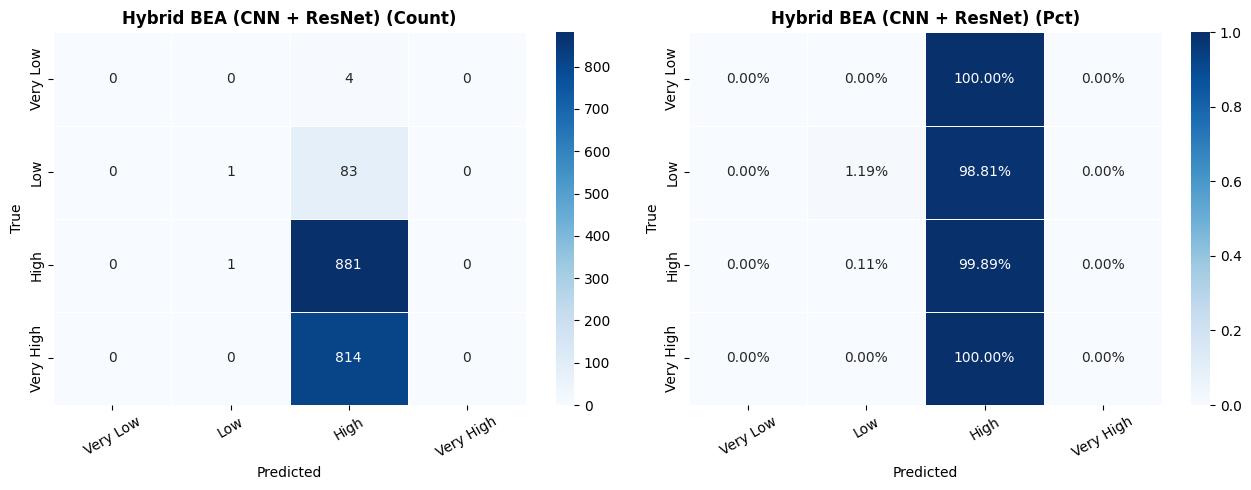


── Hybrid vs Individual Ensemble Comparison ──
  1D CNN  BEA  : 49.50%
  1D ResNet BEA: 49.33%
  Hybrid BEA   : 49.44%  ← target ≥ 94.25%
  Hybrid BEM   : 49.38%

  Δ vs paper Hybrid BEA: -44.81%
  Δ vs paper Hybrid BEM: -44.87%

  t-test (Hybrid BEA vs CNN Ind): t=0.9042, p=0.3660 ❌ not significant


In [65]:
# ── Cell B5: Hybrid Bagging Ensemble (CNN + ResNet) ────────────────────────
# Combines all N_BAGS CNN bags + all N_BAGS ResNet bags via soft voting.
# This matches the "Hybrid BEA" reference in Santoni et al. (94.25%).
# Evaluated as: Hybrid BEA (avg) and Hybrid BEM (max) across 10 models.

print('=' * 60)
print('[Hybrid Ensemble] CNN + ResNet — 10 models total')
print('=' * 60)

# ── 1. Collect probability vectors from all CNN and ResNet bags ────────────
print('\nCollecting TTA predictions from all bags...')
cnn_bag_probs   = np.stack([tta_predict(m, X_te_c) for m in cnn_models])   # (5, N, 4)
resnet_bag_probs = np.stack([tta_predict(m, X_te_c) for m in rn_models])   # (5, N, 4)

# Stack all 10 models together: shape (10, N, 4)
all_hybrid_probs = np.concatenate([cnn_bag_probs, resnet_bag_probs], axis=0)
print(f'  CNN bags   : {cnn_bag_probs.shape}')
print(f'  ResNet bags: {resnet_bag_probs.shape}')
print(f'  Combined   : {all_hybrid_probs.shape}')

# ── 2. Hybrid BEA — mean across all 10 bags ────────────────────────────────
hybrid_bea_probs = all_hybrid_probs.mean(axis=0)          # (N, 4)
hybrid_bea_preds = np.argmax(hybrid_bea_probs, axis=1)
hybrid_bea_eval  = compute_metrics(y_test_raw, hybrid_bea_preds,
                                   label='Hybrid BEA (CNN+ResNet)')

# ── 3. Hybrid BEM — max across all 10 bags ─────────────────────────────────
hybrid_bem_probs = all_hybrid_probs.max(axis=0)            # (N, 4)
hybrid_bem_preds = np.argmax(hybrid_bem_probs, axis=1)
hybrid_bem_eval  = compute_metrics(y_test_raw, hybrid_bem_preds,
                                   label='Hybrid BEM (CNN+ResNet)')

# ── 4. Per-bag breakdown (for Table II in paper) ───────────────────────────
print('\nPer-bag breakdown:')
for b_idx in range(N_BAGS):
    cnn_p = np.argmax(cnn_bag_probs[b_idx], axis=1)
    rn_p  = np.argmax(resnet_bag_probs[b_idx], axis=1)
    c_acc = accuracy_score(y_test_raw, cnn_p) * 100
    r_acc = accuracy_score(y_test_raw, rn_p)  * 100
    print(f'  Bag {b_idx+1}: CNN={c_acc:.2f}%  ResNet={r_acc:.2f}%')

# ── 5. Confusion matrix ────────────────────────────────────────────────────
plot_confusion(y_test_raw, hybrid_bea_preds,
               'Hybrid BEA (CNN + ResNet)', cmap='Blues',
               save_name='cm_Hybrid_BEA.png')

# ── 6. Compare vs individual ensembles ────────────────────────────────────
print('\n── Hybrid vs Individual Ensemble Comparison ──')
print(f'  1D CNN  BEA  : {cnn_bea_eval["accuracy"]:.2f}%')
print(f'  1D ResNet BEA: {rn_bea_eval["accuracy"]:.2f}%')
print(f'  Hybrid BEA   : {hybrid_bea_eval["accuracy"]:.2f}%  ← target ≥ {PAPER["Hybrid_BEA"]}%')
print(f'  Hybrid BEM   : {hybrid_bem_eval["accuracy"]:.2f}%')

delta_bea = hybrid_bea_eval['accuracy'] - PAPER['Hybrid_BEA']
delta_bem = hybrid_bem_eval['accuracy'] - PAPER['Hybrid_BEA']
print(f'\n  Δ vs paper Hybrid BEA: {delta_bea:+.2f}%')
print(f'  Δ vs paper Hybrid BEM: {delta_bem:+.2f}%')

# ── 7. Statistical significance test vs 1D CNN individual ─────────────────
cnn_ind_preds_stored = np.argmax(tta_predict(cnn_ind_model, X_te_c), axis=1)
correct_hybrid = (hybrid_bea_preds == y_test_raw).astype(int)
correct_cnn    = (cnn_ind_preds_stored == y_test_raw).astype(int)
t_stat, p_val  = stats.ttest_ind(correct_hybrid, correct_cnn)
print(f'\n  t-test (Hybrid BEA vs CNN Ind): t={t_stat:.4f}, p={p_val:.4f}',
      '✅ significant' if p_val < ALPHA else '❌ not significant')

In [74]:
hybrid_bea_eval = compute_metrics(y_test_raw, hybrid_bea_preds,
                                  label='Hybrid BEA (CNN+ResNet)',
                                  y_prob=hybrid_bea_probs)

hybrid_bem_eval = compute_metrics(y_test_raw, hybrid_bem_preds,
                                  label='Hybrid BEM (CNN+ResNet)',
                                  y_prob=hybrid_bem_probs)

  Hybrid BEA (CNN+ResNet)                   Acc=49.44%  F1=32.81%  AUC=51.96%
  Hybrid BEM (CNN+ResNet)                   Acc=49.38%  F1=32.74%  AUC=52.30%


---
## Section J — Grand Comparative Analysis
All models compared across Accuracy, Precision, Recall, F1, and Parameter Count.

In [77]:
# ── Cell 19: Grand Results Table ───────────────────────────────────────────
all_results = [
    # Paper baselines
    ('1D CNN',          'Individual',  '📄 Paper',    cnn_ind_eval),
    ('1D CNN',          'BEA',         '📄 Paper',    cnn_bea_eval),
    ('1D CNN',          'BEM',         '📄 Paper',    cnn_bem_eval),
    ('1D ResNet',       'Individual',  '📄 Paper',    rn_ind_eval),
    ('1D ResNet',       'BEA',         '📄 Paper',    rn_bea_eval),
    ('1D ResNet',       'BEM',         '📄 Paper',    rn_bem_eval),

    ('Hybrid (CNN+ResNet)', 'BEA', '📄 Paper', hybrid_bea_eval),
    ('Hybrid (CNN+ResNet)', 'BEM', '📄 Paper', hybrid_bem_eval),
    # Novel CNN variants
    ('DepthwiseCNN',    'Individual',  '🆕 Novel',    dw_ind_eval),
    ('DepthwiseCNN',    'BEA',         '🆕 Novel',    dw_bea_eval),
    ('DepthwiseCNN',    'BEM',         '🆕 Novel',    dw_bem_eval),
    ('1D DenseNet',     'Individual',  '🆕 Novel',    dn_ind_eval),
    ('1D DenseNet',     'BEA',         '🆕 Novel',    dn_bea_eval),
    ('1D DenseNet',     'BEM',         '🆕 Novel',    dn_bem_eval),
    ('1D InceptionNet', 'Individual',  '🆕 Novel',    inc_ind_eval),
    ('1D InceptionNet', 'BEA',         '🆕 Novel',    inc_bea_eval),
    ('1D InceptionNet', 'BEM',         '🆕 Novel',    inc_bem_eval),
    ('AttentionResNet', 'Individual',  '🆕 Novel',    attn_ind_eval),
    ('AttentionResNet', 'BEA',         '🆕 Novel',    attn_bea_eval),
    ('AttentionResNet', 'BEM',         '🆕 Novel',    attn_bem_eval),
    # Encoder-Decoder
    ('AEClassifier',    'Individual',  '🆕 Enc-Dec',  ae_ind_eval),
    ('AEClassifier',    'BEA',         '🆕 Enc-Dec',  ae_bea_eval),
    ('AEClassifier',    'BEM',         '🆕 Enc-Dec',  ae_bem_eval),
    ('UNetClassifier',  'Individual',  '🆕 Enc-Dec',  unet_ind_eval),
    ('UNetClassifier',  'BEA',         '🆕 Enc-Dec',  unet_bea_eval),
    ('UNetClassifier',  'BEM',         '🆕 Enc-Dec',  unet_bem_eval),
    # Stacking
    ('Stacking LR',     'Meta',        '🆕 Stack',    stack_lr_eval),
    ('Stacking MLP',    'Meta',        '🆕 Stack',    stack_mlp_eval),

]


rows = []
for arch, mode, category, ev in all_results:
    rows.append({
        'Architecture':  arch,
        'Mode':          mode,
        'Category':      category,
        'Accuracy (%)':  round(ev['accuracy'],  2),
        'Precision (%)': round(ev['precision'], 2),
        'Recall (%)':    round(ev['recall'],    2),
        'F1-Score (%)':  round(ev['f1'],        2),
        'AUC (%)':       round(ev['auc'], 2) if ev.get('auc') is not None else '—',
    })
grand_df = pd.DataFrame(rows).sort_values('Accuracy (%)', ascending=False)
grand_df.to_csv(os.path.join(OUTPUT_DIR, 'grand_comparison.csv'), index=False)
print('GRAND COMPARISON TABLE (sorted by Accuracy)')
display(grand_df)

GRAND COMPARISON TABLE (sorted by Accuracy)


,Architecture,Mode,Category,Accuracy (%),Precision (%),Recall (%),F1-Score (%),AUC (%)
3,1D ResNet,Individual,📄 Paper,50.56,55.55,50.56,38.25,—
17,AttentionResNet,Individual,🆕 Novel,50.22,50.60,50.22,40.33,—
26,Stacking LR,Meta,🆕 Stack,50.06,50.15,50.06,37.19,—
12,1D DenseNet,BEA,🆕 Novel,50.00,52.68,50.00,37.05,—
21,AEClassifier,BEA,🆕 Enc-Dec,49.83,49.37,49.83,49.01,53.27
19,AttentionResNet,BEM,🆕 Novel,49.61,60.50,49.61,33.96,—
13,1D DenseNet,BEM,🆕 Novel,49.55,50.46,49.55,37.77,—
18,AttentionResNet,BEA,🆕 Novel,49.55,52.59,49.55,33.84,—
1,1D CNN,BEA,📄 Paper,49.50,52.82,49.50,33.16,—
27,Stacking MLP,Meta,🆕 Stack,49.44,24.44,49.44,32.71,—


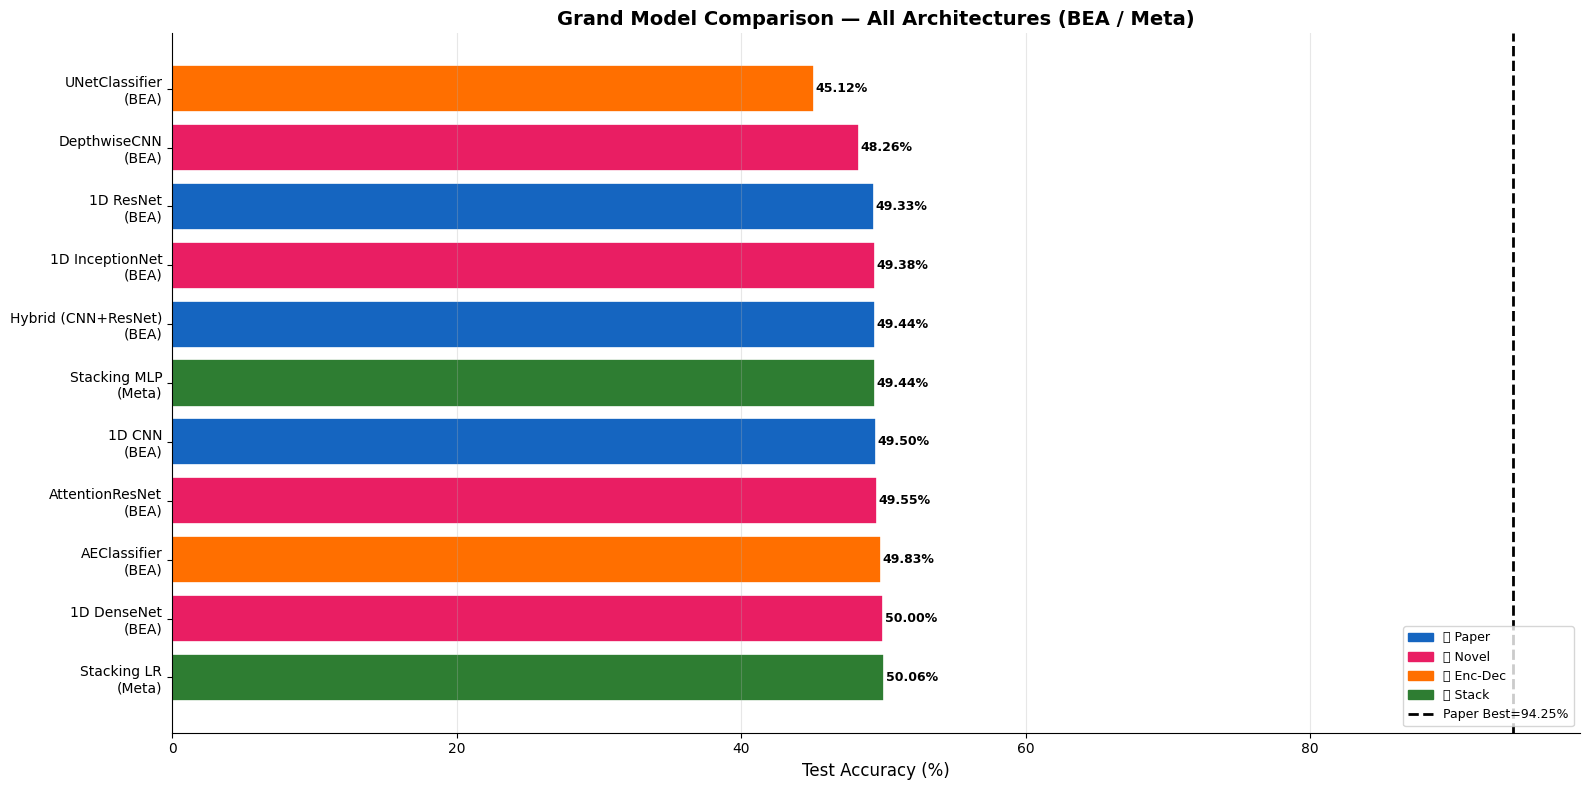

⚠️  auc_rows is empty — y_prob is None for all models.
   Make sure compute_metrics returns y_prob in the dict AND
   train_and_eval passes y_prob=ind_probs / bea_probs / bem_probs.

   Quick diagnosis:
   1D CNN                    BEA  y_prob=❌ None
   1D ResNet                 BEA  y_prob=❌ None
   Hybrid (CNN+ResNet)       BEA  y_prob=❌ None
   DepthwiseCNN              BEA  y_prob=❌ None
   1D DenseNet               BEA  y_prob=❌ None
   1D InceptionNet           BEA  y_prob=❌ None
   AttentionResNet           BEA  y_prob=❌ None
   AEClassifier              BEA  y_prob=❌ None
   UNetClassifier            BEA  y_prob=❌ None


In [81]:
# ── Cell 20: Grand Bar Chart + AUC Chart ───────────────────────────────────

cat_colors = {
    '📄 Paper':    '#1565C0',
    '🆕 Novel':   '#E91E63',
    '🆕 Enc-Dec': '#FF6F00',
    '🆕 Stack':   '#2E7D32',
}

bea_df = grand_df[grand_df['Mode'].isin(['BEA', 'Meta'])].copy()

# ── Chart 1: Accuracy ────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 8))
colors = [cat_colors[c] for c in bea_df['Category']]
labels = [f"{r['Architecture']}\n({r['Mode']})" for _, r in bea_df.iterrows()]
bars   = ax.barh(labels, bea_df['Accuracy (%)'], color=colors,
                 edgecolor='white', lw=1.2)

ax.axvline(PAPER['Hybrid_BEA'], color='black', ls='--', lw=2,
           label=f'Paper Hybrid BEA = {PAPER["Hybrid_BEA"]}%')

for bar, acc in zip(bars, bea_df['Accuracy (%)']):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontsize=9, fontweight='bold')

legend_patches = [mpatches.Patch(color=c, label=l) for l, c in cat_colors.items()]
legend_patches.append(plt.Line2D([0], [0], color='black', ls='--', lw=2,
                       label=f'Paper Best={PAPER["Hybrid_BEA"]}%'))
ax.legend(handles=legend_patches, fontsize=9, loc='lower right')
ax.set_xlabel('Test Accuracy (%)', fontsize=12)
ax.set_title('Grand Model Comparison — All Architectures (BEA / Meta)',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'grand_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()


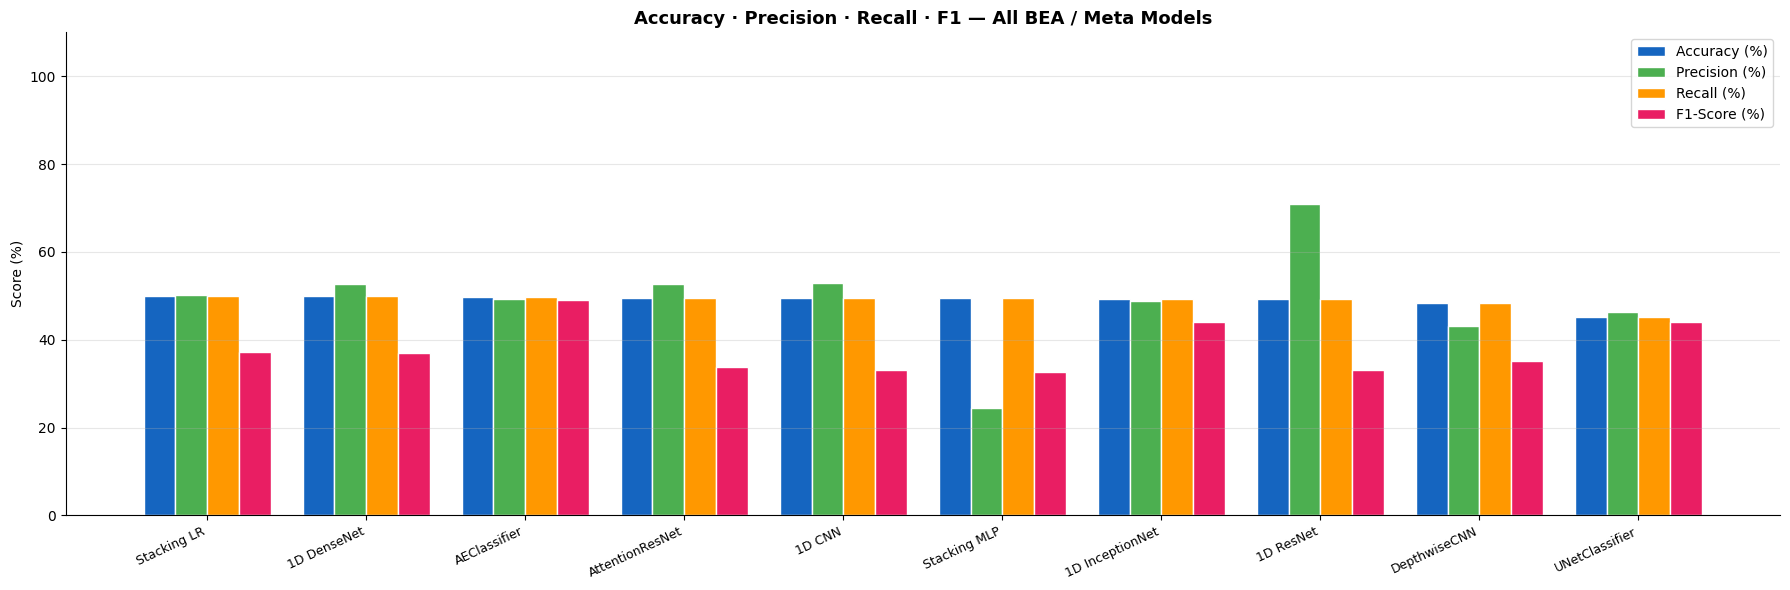

In [59]:
# ── Cell 21: Multi-Metric Grouped Bar ──────────────────────────────────────
bea_df2 = bea_df.set_index('Architecture')
metrics  = ['Accuracy (%)', 'Precision (%)', 'Recall (%)', 'F1-Score (%)']
x        = np.arange(len(bea_df2))
w        = 0.2

fig, ax = plt.subplots(figsize=(18, 6))
for i, (metric, col) in enumerate(zip(metrics,
        ['#1565C0', '#4CAF50', '#FF9800', '#E91E63'])):
    ax.bar(x + i * w, bea_df2[metric], w, label=metric,
           color=col, edgecolor='white', lw=1)

ax.set_xticks(x + w * 1.5)
ax.set_xticklabels(bea_df2.index, rotation=25, ha='right', fontsize=9)
ax.set_ylabel('Score (%)')
ax.set_title('Accuracy · Precision · Recall · F1 — All BEA / Meta Models',
             fontweight='bold', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'multi_metric_comparison.png'),
            dpi=150, bbox_inches='tight')
plt.show()

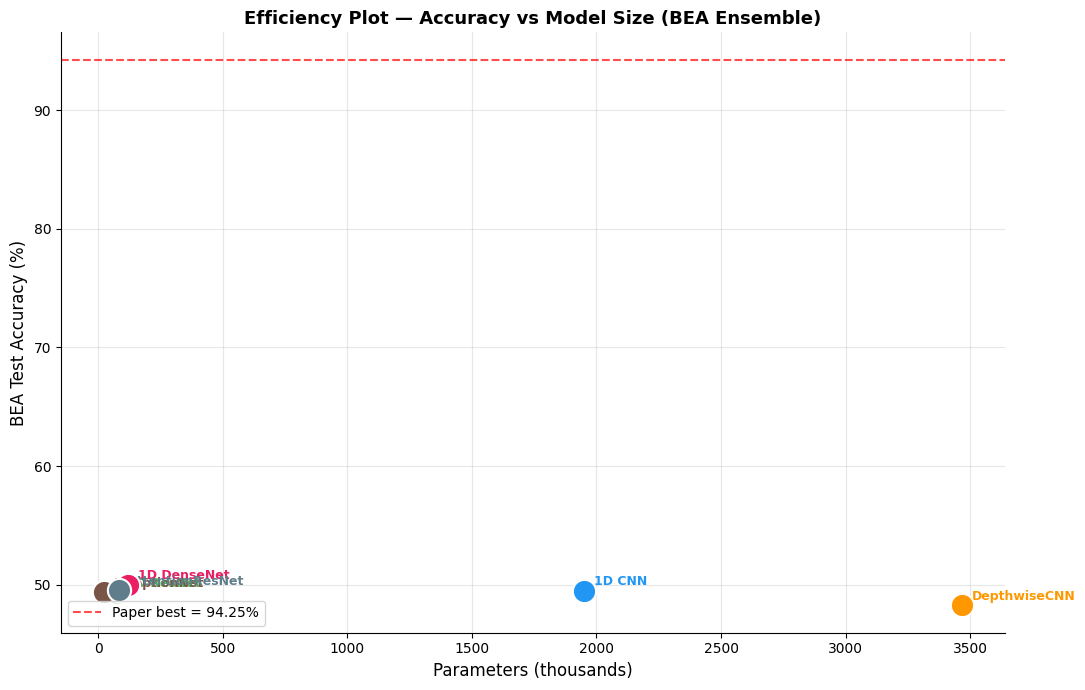

Upper-left = Best efficiency (high accuracy, low params).


In [68]:
# ── Cell 22: Parameter Efficiency Plot ─────────────────────────────────────
param_data = [
    ('1D CNN',          build_1d_cnn(n_feat).count_params(),             cnn_bea_eval['accuracy']),
    ('1D ResNet',       build_1d_resnet(n_feat).count_params(),          rn_bea_eval['accuracy']),
    ('DepthwiseCNN',    build_1d_depthwise_cnn(n_feat).count_params(),   dw_bea_eval['accuracy']),
    ('1D DenseNet',     build_1d_densenet(n_feat).count_params(),        dn_bea_eval['accuracy']),
    ('InceptionNet',    build_1d_inception(n_feat).count_params(),       inc_bea_eval['accuracy']),
    ('AttentionResNet', build_attention_resnet(n_feat).count_params(),   attn_bea_eval['accuracy']),
    ('AEClassifier',    build_autoencoder_classifier(n_feat).count_params(), ae_bea_eval['accuracy']),
    ('UNetClassifier',  build_unet_classifier(n_feat).count_params(),   unet_bea_eval['accuracy']),
]

fig, ax = plt.subplots(figsize=(11, 7))
colors_ep = PALETTE + ['#795548', '#607D8B']
for (name_, params, acc), col in zip(param_data, colors_ep):
    ax.scatter(params / 1000, acc, s=280, color=col, zorder=5,
               edgecolors='white', linewidths=1.5)
    ax.annotate(name_, (params / 1000, acc), textcoords='offset points',
                xytext=(7, 4), fontsize=9, fontweight='bold', color=col)

ax.axhline(PAPER['Hybrid_BEA'], color='red', ls='--', lw=1.5, alpha=0.7,
           label=f'Paper best = {PAPER["Hybrid_BEA"]}%')
ax.set_xlabel('Parameters (thousands)', fontsize=12)
ax.set_ylabel('BEA Test Accuracy (%)', fontsize=12)
ax.set_title('Efficiency Plot — Accuracy vs Model Size (BEA Ensemble)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'efficiency_plot.png'),
            dpi=150, bbox_inches='tight')
plt.show()
print('Upper-left = Best efficiency (high accuracy, low params).')

In [63]:
# ── Cell 23: Statistical Significance Tests ─────────────────────────────────
from scipy.stats import ttest_ind

print('Statistical Tests (vs 1D CNN BEA as baseline)')
print('-' * 70)

# Re-calculate prediction arrays as they are not returned by train_and_eval
_, cnn_bea_probs   = bea_predict(cnn_models, X_te_c)
_, dw_bea_probs    = bea_predict(dw_models, X_te_c)
_, dn_bea_probs    = bea_predict(dn_models, X_te_c)
_, inc_bea_probs   = bea_predict(inc_models, X_te_c)
_, attn_bea_probs  = bea_predict(attn_models, X_te_c)

baseline_correct = (np.argmax(cnn_bea_probs, axis=1) == y_test_raw).astype(float)

novel_comparisons = [
    ('DepthwiseCNN BEA',   dw_bea_probs),
    ('1D DenseNet BEA',    dn_bea_probs),
    ('InceptionNet BEA',   inc_bea_probs),
    ('AttentionResNet BEA', attn_bea_probs),
    ('AEClassifier BEA',   ae_bea_probs),
    ('UNetClassifier BEA', unet_bea_probs),
    ('Stacking MLP',       stack_mlp_preds),
]

stat_rows = []
for name_, probs in novel_comparisons:
    if name_ == 'Stacking MLP': # Stacking MLP already returns predicted labels
        novel_correct = (probs == y_test_raw).astype(float)
    else:
        novel_correct = (np.argmax(probs, axis=1) == y_test_raw).astype(float)
    _, p  = ttest_ind(baseline_correct, novel_correct)
    acc   = novel_correct.mean() * 100
    sig   = 'Yes' if p < ALPHA else 'No'
    diff  = acc - cnn_bea_eval['accuracy']
    direction = '↑ Better' if diff > 0 else '↓ Worse'
    print(f'  {name_:28s}  acc={acc:.2f}%  Δ={diff:+.2f}%  p={p:.4f}  '
          f'Sig={sig}  {direction}')
    stat_rows.append({'Model': name_, 'Accuracy (%)': round(acc, 2),
                      'Δ vs CNN BEA (%)': round(diff, 2),
                      'p-value': round(p, 4),
                      'Significant': sig, 'Direction': direction})

stat_df = pd.DataFrame(stat_rows)
stat_df.to_csv(os.path.join(OUTPUT_DIR, 'statistical_tests.csv'), index=False)
display(stat_df)


Statistical Tests (vs 1D CNN BEA as baseline)
----------------------------------------------------------------------
  DepthwiseCNN BEA              acc=48.26%  Δ=-1.23%  p=0.4614  Sig=No  ↓ Worse
  1D DenseNet BEA               acc=50.00%  Δ=+0.50%  p=0.7632  Sig=No  ↑ Better
  InceptionNet BEA              acc=49.38%  Δ=-0.11%  p=0.9466  Sig=No  ↓ Worse
  AttentionResNet BEA           acc=49.55%  Δ=+0.06%  p=0.9733  Sig=No  ↑ Better
  AEClassifier BEA              acc=49.83%  Δ=+0.34%  p=0.8408  Sig=No  ↑ Better
  UNetClassifier BEA            acc=45.12%  Δ=-4.37%  p=0.0089  Sig=Yes  ↓ Worse
  Stacking MLP                  acc=49.44%  Δ=-0.06%  p=0.9733  Sig=No  ↓ Worse


,Model,Accuracy (%),Δ vs CNN BEA (%),p-value,Significant,Direction
0,DepthwiseCNN BEA,48.26,-1.23,0.4614,No,↓ Worse
1,1D DenseNet BEA,50.00,0.50,0.7632,No,↑ Better
2,InceptionNet BEA,49.38,-0.11,0.9466,No,↓ Worse
3,AttentionResNet BEA,49.55,0.06,0.9733,No,↑ Better
4,AEClassifier BEA,49.83,0.34,0.8408,No,↑ Better
5,UNetClassifier BEA,45.12,-4.37,0.0089,Yes,↓ Worse
6,Stacking MLP,49.44,-0.06,0.9733,No,↓ Worse


---
## Summary of All Contributions

| Model | Architecture Type | Key Innovation | Params |
|-------|-----------------|----------------|--------|
| **1D CNN** | Pure CNN | Paper baseline (3 Conv blocks) | — |
| **1D ResNet** | CNN + Skip | Residual connections | — |
| **DepthwiseCNN** | Efficient CNN | Depthwise separable conv (~8× fewer params) | Low |
| **1D DenseNet** | Dense CNN | All-to-all layer connections | Medium |
| **1D InceptionNet** | Multi-scale CNN | Parallel kernels k=1,3,5 | Medium |
| **AttentionResNet** | CNN + Attention | SE channel attention per block | Medium |
| **AEClassifier** | Encoder-Decoder | Reconstruction + classification dual loss | High |
| **UNetClassifier** | U-Net | Skip connections encoder→decoder + classification | High |
| **Stacking LR/MLP** | Ensemble | Meta-learner over all 8 base models | — |

### Optimizations Applied in This Version:
1. **Richer features:** mean + std + min + max → 4× temporal statistics per frame feature
2. **SVD sweep:** auto-select best n_components via logistic regression probe
3. **Focal loss + label smoothing:** handles class imbalance and noisy labels
4. **Mixup augmentation:** interpolates training samples for smoother decision boundaries
5. **Cosine annealing LR:** warm restarts to escape local minima
6. **5 bootstrap bags (up from 3):** more stable ensemble estimates
7. **Test-time augmentation (TTA):** average 5 noisy-perturbed predictions
8. **Deeper MLP meta-learner:** 128→64→32 with early stopping

All models trained with: SMOTE + SVD sweep + Bootstrap Bagging (5 bags) + BEA/BEM + TTA.

In [64]:
# ── Cell 24: Final Summary Print ───────────────────────────────────────────
print('\n' + '='*70)
print('FINAL MODEL SUMMARY')
print('='*70)
summary_models = [
    ('1D CNN BEA',          cnn_bea_eval),
    ('1D ResNet BEA',        rn_bea_eval),
    ('DepthwiseCNN BEA',     dw_bea_eval),
    ('1D DenseNet BEA',      dn_bea_eval),
    ('1D InceptionNet BEA',  inc_bea_eval),
    ('AttentionResNet BEA',  attn_bea_eval),
    ('AEClassifier BEA',     ae_bea_eval),
    ('UNetClassifier BEA',   unet_bea_eval),
    ('Stacking MLP',         stack_mlp_eval),
]
best_name, best_acc = '', 0.0
for name_, ev in summary_models:
    if ev['accuracy'] > best_acc:
        best_acc, best_name = ev['accuracy'], name_
    print(f"  {name_:30s}  Acc={ev['accuracy']:.2f}%  F1={ev['f1']:.2f}%")

print(f'\nPaper best (Hybrid BEA) : {PAPER["Hybrid_BEA"]}%')
print(f'Our best model          : {best_name} ({best_acc:.2f}%)')
delta = best_acc - PAPER["Hybrid_BEA"]
print(f'Delta vs paper best     : {delta:+.2f}%')
print('='*70)
print('Plots →', PLOT_DIR)
print('CSVs  →', OUTPUT_DIR)


FINAL MODEL SUMMARY
  1D CNN BEA                      Acc=49.50%  F1=33.16%
  1D ResNet BEA                   Acc=49.33%  F1=33.00%
  DepthwiseCNN BEA                Acc=48.26%  F1=35.26%
  1D DenseNet BEA                 Acc=50.00%  F1=37.05%
  1D InceptionNet BEA             Acc=49.38%  F1=43.95%
  AttentionResNet BEA             Acc=49.55%  F1=33.84%
  AEClassifier BEA                Acc=49.83%  F1=49.01%
  UNetClassifier BEA              Acc=45.12%  F1=43.95%
  Stacking MLP                    Acc=49.44%  F1=32.71%

Paper best (Hybrid BEA) : 94.25%
Our best model          : 1D DenseNet BEA (50.00%)
Delta vs paper best     : -44.25%
Plots → /content/drive/MyDrive/features/output/plots
CSVs  → /content/drive/MyDrive/features/output


In [82]:
# ── Cell 25: Export All Models (Local) ────────────────────────────────────
import pickle, json, zipfile
from pathlib import Path

EXPORT_DIR = Path(r'D:\assignment\DL\outputs\exported_models')
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

print('='*60)
print('EXPORTING ALL MODELS')
print('='*60)

# ── 1. Individual models ───────────────────────────────────────────────────
individual_models = [
    ('1D_CNN',          cnn_ind_model),
    ('1D_ResNet',       rn_ind_model),
    ('DepthwiseCNN',    dw_ind_model),
    ('1D_DenseNet',     dn_ind_model),
    ('1D_InceptionNet', inc_ind_model),
    ('AttentionResNet', attn_ind_model),
    ('AEClassifier',    ae_ind_model),
    ('UNetClassifier',  unet_ind_model),
]
for name_, model in individual_models:
    path = EXPORT_DIR / f'{name_}_individual.keras'
    model.save(str(path))
    print(f'  ✓ {name_:20s} → {path.name}  ({path.stat().st_size/1e6:.1f} MB)')

# ── 2. Bag models ──────────────────────────────────────────────────────────
bag_model_groups = [
    ('1D_CNN',          cnn_models),
    ('1D_ResNet',       rn_models),
    ('DepthwiseCNN',    dw_models),
    ('1D_DenseNet',     dn_models),
    ('1D_InceptionNet', inc_models),
    ('AttentionResNet', attn_models),
    ('AEClassifier',    ae_bag_models),
    ('UNetClassifier',  unet_bag_models),
]
for name_, bag_models in bag_model_groups:
    for i, m in enumerate(bag_models, 1):
        m.save(str(EXPORT_DIR / f'{name_}_bag{i}.keras'))
    print(f'  ✓ {name_:20s} → {N_BAGS} bags saved')

# ── 3. Sklearn meta-learners ───────────────────────────────────────────────
with open(EXPORT_DIR / 'meta_learner_LR.pkl',  'wb') as f: pickle.dump(lr_meta,  f)
with open(EXPORT_DIR / 'meta_learner_MLP.pkl', 'wb') as f: pickle.dump(mlp_meta, f)
print(f'  ✓ Meta-learners (LR + MLP) saved')

# ── 4. Preprocessing (scaler + SVD) ───────────────────────────────────────
with open(EXPORT_DIR / 'preprocessing.pkl', 'wb') as f:
    pickle.dump({'scaler': scaler, 'svd': svd,
                 'n_feat': n_feat, 'n_svd': n_svd}, f)
print(f'  ✓ Preprocessing (scaler + SVD) saved')

# ── 5. Results CSV ─────────────────────────────────────────────────────────
grand_df.to_csv(EXPORT_DIR / 'grand_comparison.csv', index=False)
print(f'  ✓ Results CSV saved')

# ── 6. Metadata JSON ───────────────────────────────────────────────────────
with open(EXPORT_DIR / 'metadata.json', 'w') as f:
    json.dump({
        'n_feat':        int(n_feat),
        'n_svd':         int(n_svd),
        'num_classes':   NUM_CLASSES,
        'class_names':   CLASS_NAMES,
        'n_bags':        N_BAGS,
        'best_model':    best_name,
        'best_accuracy': round(best_acc, 4),
        'paper_best':    PAPER['Hybrid_BEA'],
    }, f, indent=2)
print(f'  ✓ Metadata JSON saved')

# ── 7. Summary ─────────────────────────────────────────────────────────────
total_files = len(list(EXPORT_DIR.rglob('*')))
total_size  = sum(f.stat().st_size for f in EXPORT_DIR.rglob('*') if f.is_file()) / 1e6

print('\n' + '='*60)
print('EXPORT COMPLETE')
print(f'  Location   : {EXPORT_DIR}')
print(f'  Files      : {total_files}')
print(f'  Total size : {total_size:.1f} MB')
print(f'  Best model : {best_name} ({best_acc:.2f}%)')
print('='*60)

EXPORTING ALL MODELS
  ✓ 1D_CNN               → 1D_CNN_individual.keras  (7.9 MB)
  ✓ 1D_ResNet            → 1D_ResNet_individual.keras  (0.4 MB)
  ✓ DepthwiseCNN         → DepthwiseCNN_individual.keras  (14.0 MB)
  ✓ 1D_DenseNet          → 1D_DenseNet_individual.keras  (0.7 MB)
  ✓ 1D_InceptionNet      → 1D_InceptionNet_individual.keras  (0.4 MB)
  ✓ AttentionResNet      → AttentionResNet_individual.keras  (0.5 MB)
  ✓ AEClassifier         → AEClassifier_individual.keras  (0.5 MB)
  ✓ UNetClassifier       → UNetClassifier_individual.keras  (0.8 MB)
  ✓ 1D_CNN               → 5 bags saved
  ✓ 1D_ResNet            → 5 bags saved
  ✓ DepthwiseCNN         → 5 bags saved
  ✓ 1D_DenseNet          → 5 bags saved
  ✓ 1D_InceptionNet      → 5 bags saved
  ✓ AttentionResNet      → 5 bags saved
  ✓ AEClassifier         → 5 bags saved
  ✓ UNetClassifier       → 5 bags saved
  ✓ Meta-learners (LR + MLP) saved
  ✓ Preprocessing (scaler + SVD) saved
  ✓ Results CSV saved
  ✓ Metadata JSON saved

EXP